$$\Huge{\text{Learning Simulations}}$$

In [ ]:
!pip install /home/mahdi/python_projects/SLIM

In [2]:
%autoreload 2
import sys
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib as mpl
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
mpl.rcParams['text.usetex'] = True

from tqdm.notebook import tqdm

from slim.model import SLIM
from slim.utils import *
from slim import viz

sys.path.insert(0, '/home/mahdi/python_projects/slim_development/')
from slim_development.behavioral_utils import calculate_MLE, get_sequence, _jsd_avg


sns.set(style='whitegrid', context='talk')

ibm_palette = [ '#648fff', '#dc267f', '#fe6100', '#ffb000', '#785ef0', '#8be04e', '#009e73', '#56b4e9']
sns.set_palette(ibm_palette)

---

# Learning Stationary World Dynamics

---

### Generate Sequences

In [3]:
deterministic_dynamics_matrix = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])
deterministic_sequence = np.array([0, 1, 2]*30)
dim = len(np.unique(deterministic_sequence))

stochastic_dynamics_matrix = np.array([[.1,.8,.1],
                                       [.1,.1,.8],
                                       [.8,.1,.1]])
x = 0
stochastic_sequence = [x]
for i in range(len(deterministic_sequence)-1):
    x = np.random.choice(np.arange(0,3), p=stochastic_dynamics_matrix[x])
    stochastic_sequence.append(x)

### Define Sensors

In [4]:
sensor = sensor_eye(dim)
noisy_sensor = sensor_eye(dim, gaussian={'sigma': 0.3, 'mode': 'reflect'})
very_noisy_sensor = sensor_eye(dim, gaussian={'sigma': 0.5, 'mode': 'reflect'})

In [5]:
def plot_inset(ax, model, seq):
    axins = ax.inset_axes([0.1+0.5, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==0], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('A')

    axins = ax.inset_axes([0.1+0.65, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==1], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('B')

    axins = ax.inset_axes([0.1+0.8, -0.1, 0.15, 0.15])
    sns.barplot(model.bel[i_half:][np.array(seq)[i_half:]==2], ax=axins)
    axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    axins.set_title('C')

### Fit Models

In [6]:
learning_rate = .1

# model definitions
low = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
low_sensor_noise = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
low_process_noise = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
low_then_sensor_off = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')

low_process_and_sensor_noise = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
high_sensor_noise = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
high_process_and_sensor_noise = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
low_process_then_sensor_off = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')

loop = tqdm(range(0, len(deterministic_sequence)))
for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[deterministic_sequence[t]]
    low.step(h, learning_rate=learning_rate)

    h_sensor_noise = noisy_sensor[deterministic_sequence[t]]
    low_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)

    if t < len(deterministic_sequence)//2:
        low_then_sensor_off.step(h_sensor_noise, learning_rate=learning_rate)
    else:
        low_then_sensor_off.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate)

    h_sensor_noise = very_noisy_sensor[deterministic_sequence[t]]
    high_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)


for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[stochastic_sequence[t]]
    low_process_noise.step(h, learning_rate=learning_rate)

    h_sensor_noise = noisy_sensor[stochastic_sequence[t]]
    low_process_and_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)

    if t < len(stochastic_sequence)//2:
        low_process_then_sensor_off.step(h_sensor_noise, learning_rate=learning_rate)
    else:
        low_process_then_sensor_off.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate)

    h_sensor_noise = very_noisy_sensor[stochastic_sequence[t]]
    high_process_and_sensor_noise.step(h_sensor_noise, learning_rate=learning_rate)


  0%|          | 0/90 [00:00<?, ?it/s]

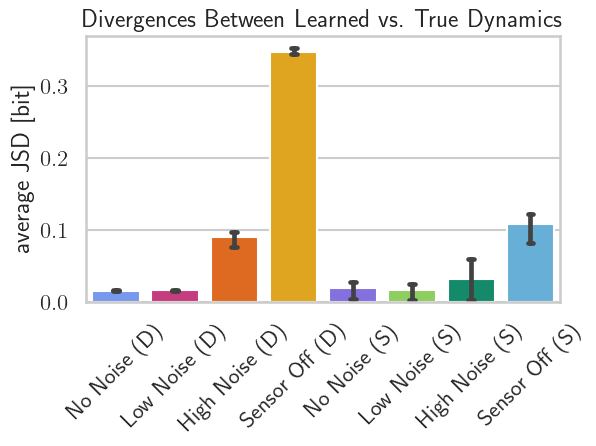

In [7]:
models = [low, low_sensor_noise, high_sensor_noise, low_then_sensor_off ,
          low_process_noise, low_process_and_sensor_noise,high_process_and_sensor_noise,low_process_then_sensor_off ]

simulation_1_jsd_results = np.array([
    np.array([jsd(p, q) for p,q in zip(m.W, gt)]) #jsd_avg(m.W, gt)
    for gt, m in zip([deterministic_dynamics_matrix]*4 +[stochastic_dynamics_matrix]*4, models)
]).T

ax = sns.barplot(simulation_1_jsd_results, capsize=0.1)
ax.set_xticks(range(8), ['No Noise (D)','Low Noise (D)','High Noise (D)','Sensor Off (D)',
                         'No Noise (S)','Low Noise (S)','High Noise (S)','Sensor Off (S)'], rotation=45)
plt.title('Divergences Between Learned vs. True Dynamics')
plt.ylabel('average JSD [bit]')
plt.tight_layout()
plt.savefig('./results/simulation1_jsds_bar.png', dpi=300)
plt.show()

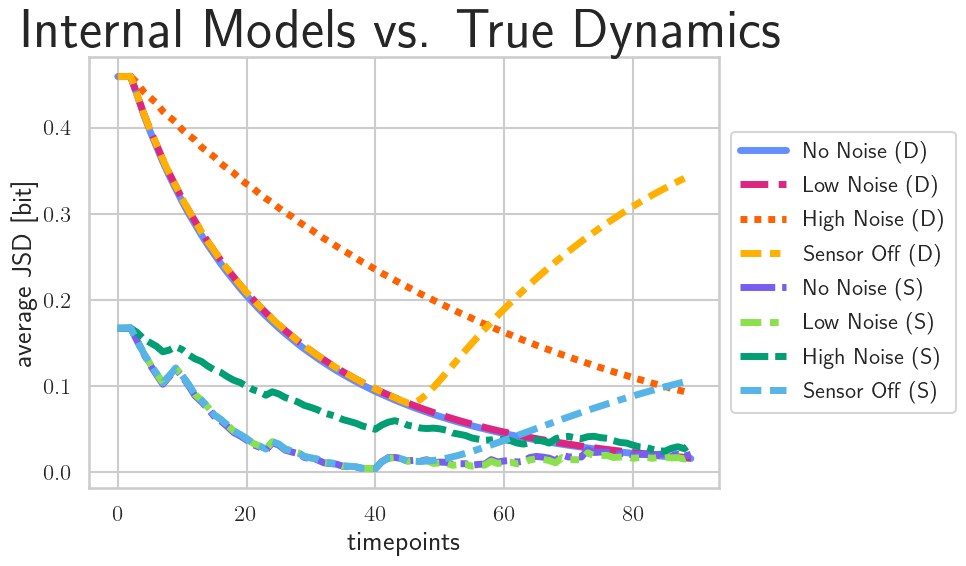

In [8]:
models = [low, low_sensor_noise, high_sensor_noise, low_then_sensor_off ,
          low_process_noise, low_process_and_sensor_noise,high_process_and_sensor_noise,low_process_then_sensor_off ]

simulation_1_jsd_results = np.array([
    [jsd_avg(W, gt) for W in m.W_hist]
    for gt, m in zip([deterministic_dynamics_matrix]*4 +[stochastic_dynamics_matrix]*4, models)
]).T

df = pd.DataFrame(simulation_1_jsd_results, columns=['No Noise (D)','Low Noise (D)','High Noise (D)','Sensor Off (D)', 'No Noise (S)','Low Noise (S)','High Noise (S)','Sensor Off (S)'])
# ax = sns.barplot(simulation_1_jsd_results, capsize=0.1)
# ax.set_xticks(range(8), ['No Noise (D)','Low Noise (D)','High Noise (D)','Sensor Off (D)',
#                          'No Noise (S)','Low Noise (S)','High Noise (S)','Sensor Off (S)'], rotation=45)

plt.figure(figsize=(10,6))
ax = sns.lineplot(df, linewidth=5)
plt.ylabel('average JSD [bit]', fontsize=20, fontweight='bold')
plt.xlabel('timepoints', fontsize=20, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Internal Models vs. True Dynamics', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/simulation1_jsds.png', transparent=True, bbox_inches='tight')
plt.show()

### Plot Results

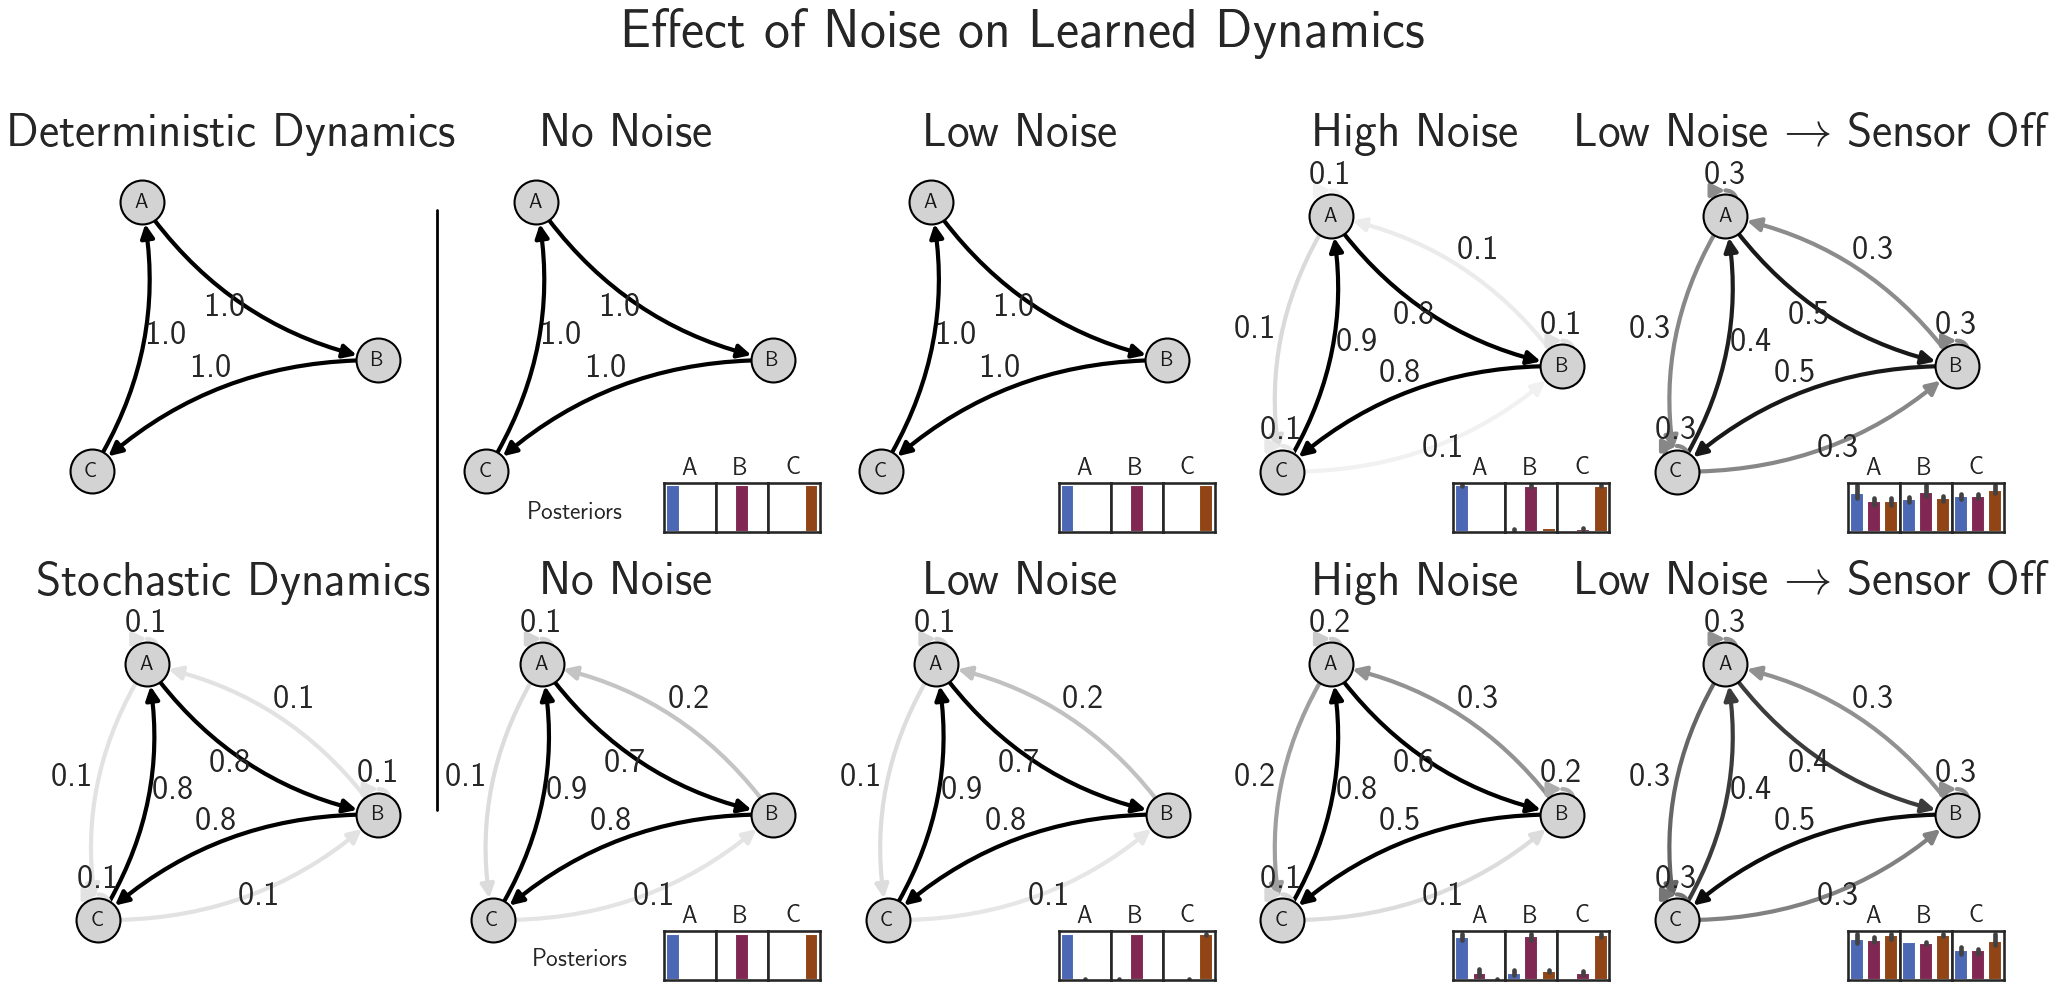

In [9]:
sns.set(style='white', context='talk')
ibm_palette = [ '#648fff', '#dc267f', '#fe6100', '#ffb000', '#785ef0', '#8be04e', '#009e73', '#56b4e9']
ibm_palette_darker = ['#3b5fc4','#8f1953','#a63f00','#a86f00','#4a37b8', '#8be04e', '#009e73', '#56b4e9']
sns.set_palette(ibm_palette_darker)

fig, ax = plt.subplots(2, 5, figsize=(5*4, 5*2))
fig.add_artist(plt.Line2D([0.205, 0.205], [0.2, 0.8], transform=fig.transFigure, color='black', linewidth=2, linestyle='-'))

i_half = len(deterministic_sequence)//2

thr = 0.05
states = ['A', 'B', 'C']
G_layout = nx.DiGraph()
G_layout.add_nodes_from(states)
pos = nx.spring_layout(G_layout, seed=42)

true_model = SLIM(dim, model_name='Deterministic Dynamics')
true_model.W = np.array([[0., 1., 0.],
                         [0., 0., 1.],
                         [1., 0., 0.]])
viz.create_digraph(true_model, states, ax[0][0], thr=thr)

viz.create_digraph(low, states, ax[0][1], thr=thr)
plot_inset(ax[0][1], low, deterministic_sequence)

viz.create_digraph(low_sensor_noise, states, ax[0][2], thr=thr)
plot_inset(ax[0][2], low_sensor_noise, deterministic_sequence)

viz.create_digraph(high_sensor_noise, states, ax[0][3], thr=thr)
plot_inset(ax[0][3], high_sensor_noise, deterministic_sequence)

viz.create_digraph(low_then_sensor_off, states, ax[0][4], thr=thr)
plot_inset(ax[0][4], low_then_sensor_off, deterministic_sequence)

####################### stochastic deterministic_sequence

true_model = SLIM(dim, model_name='Stochastic Dynamics')
true_model.W = stochastic_dynamics_matrix
viz.create_digraph(true_model, states, ax[1][0], thr=thr)

viz.create_digraph(low_process_noise, states, ax[1][1], thr=thr)
plot_inset(ax[1][1], low_process_noise, stochastic_sequence)

viz.create_digraph(low_process_and_sensor_noise, states, ax[1][2], thr=thr)
plot_inset(ax[1][2], low_process_and_sensor_noise, stochastic_sequence)

viz.create_digraph(high_process_and_sensor_noise, states, ax[1][3], thr=thr)
plot_inset(ax[1][3], high_process_and_sensor_noise, stochastic_sequence)

viz.create_digraph(low_process_then_sensor_off, states, ax[1][4], thr=thr)
plot_inset(ax[1][4], low_process_then_sensor_off, stochastic_sequence)

ax[1][1].text(-.4,-1.2, 'Posteriors')
ax[0][1].text(-.4,-1.2, 'Posteriors')

# Noise Effect
plt.suptitle(r'Effect of Noise on Learned Dynamics', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/learned_dynamics_with_posteriors.png', transparent=True, bbox_inches='tight')
plt.show()

###########################################

sns.set_palette(ibm_palette)


In [10]:
#
model_names = ['No Noise (D)', 'Low Noise (D)', 'High Noise (D)', 'Sensor Off (D)']
data = []
index = []
for m, n in zip([low, low_sensor_noise, high_sensor_noise, low_then_sensor_off], model_names):
    for state in range(3):
        vals = m.bel[i_half:][deterministic_sequence[i_half:]==state]
        data += [[f"{m:.4f} ± {s:.4f}" for m, s in zip(vals.mean(axis=0), vals.std(axis=0))]]
        index.append(n)

model_names = ['No Noise (S)', 'Low Noise (S)', 'High Noise (S)', 'Sensor Off (S)']
for m, n in zip([low_process_noise, low_process_and_sensor_noise, high_process_and_sensor_noise, low_process_then_sensor_off], model_names):
    for state in range(3):
        vals = m.bel[i_half:][np.array(stochastic_sequence)[i_half:]==state]
        data += [[f"{m:.4f} ± {s:.4f}" for m, s in zip(vals.mean(axis=0), vals.std(axis=0))]]
        index.append(n)

df_posteriors = pd.DataFrame(
    data,
    columns=['A', 'B', 'C'],
    index=index
)

display(df_posteriors)

df_posteriors.to_latex(
    float_format="%.4f",
    caption="Posteior Distributions in Simulation 1",
    label="tab:simulation1_posteriors",
)


,A,B,C
No Noise (D),1.0000 ± 0.0000,0.0000 ± 0.0000,0.0000 ± 0.0000
No Noise (D),0.0000 ± 0.0000,1.0000 ± 0.0000,0.0000 ± 0.0000
No Noise (D),0.0000 ± 0.0000,0.0000 ± 0.0000,1.0000 ± 0.0000
Low Noise (D),0.9996 ± 0.0002,0.0004 ± 0.0002,0.0000 ± 0.0000
Low Noise (D),0.0003 ± 0.0002,0.9993 ± 0.0003,0.0004 ± 0.0002
Low Noise (D),0.0000 ± 0.0000,0.0003 ± 0.0002,0.9997 ± 0.0002
High Noise (D),0.9626 ± 0.0130,0.0341 ± 0.0122,0.0033 ± 0.0009
High Noise (D),0.0373 ± 0.0121,0.8918 ± 0.0296,0.0709 ± 0.0174
High Noise (D),0.0037 ± 0.0010,0.0582 ± 0.0167,0.9381 ± 0.0178
Sensor Off (D),0.3857 ± 0.1348,0.3065 ± 0.0664,0.3079 ± 0.0684


'\\begin{table}\n\\caption{Posteior Distributions in Simulation 1}\n\\label{tab:simulation1_posteriors}\n\\begin{tabular}{llll}\n\\toprule\n & A & B & C \\\\\n\\midrule\nNo Noise (D) & 1.0000 ± 0.0000 & 0.0000 ± 0.0000 & 0.0000 ± 0.0000 \\\\\nNo Noise (D) & 0.0000 ± 0.0000 & 1.0000 ± 0.0000 & 0.0000 ± 0.0000 \\\\\nNo Noise (D) & 0.0000 ± 0.0000 & 0.0000 ± 0.0000 & 1.0000 ± 0.0000 \\\\\nLow Noise (D) & 0.9996 ± 0.0002 & 0.0004 ± 0.0002 & 0.0000 ± 0.0000 \\\\\nLow Noise (D) & 0.0003 ± 0.0002 & 0.9993 ± 0.0003 & 0.0004 ± 0.0002 \\\\\nLow Noise (D) & 0.0000 ± 0.0000 & 0.0003 ± 0.0002 & 0.9997 ± 0.0002 \\\\\nHigh Noise (D) & 0.9626 ± 0.0130 & 0.0341 ± 0.0122 & 0.0033 ± 0.0009 \\\\\nHigh Noise (D) & 0.0373 ± 0.0121 & 0.8918 ± 0.0296 & 0.0709 ± 0.0174 \\\\\nHigh Noise (D) & 0.0037 ± 0.0010 & 0.0582 ± 0.0167 & 0.9381 ± 0.0178 \\\\\nSensor Off (D) & 0.3857 ± 0.1348 & 0.3065 ± 0.0664 & 0.3079 ± 0.0684 \\\\\nSensor Off (D) & 0.3088 ± 0.0512 & 0.3757 ± 0.1022 & 0.3156 ± 0.0510 \\\\\nSensor Off (D)

---

# Add Baselines

In [11]:
learning_rate = .1

# model definitions

low_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
low_fixed_W.W = deterministic_dynamics_matrix

low_sensor_noise_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
low_sensor_noise_fixed_W.W = deterministic_dynamics_matrix

high_sensor_noise_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
high_sensor_noise_fixed_W.W = deterministic_dynamics_matrix

low_then_sensor_off_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')
low_then_sensor_off_fixed_W.W = deterministic_dynamics_matrix

low_process_and_sensor_noise_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
low_process_and_sensor_noise_fixed_W.W = stochastic_dynamics_matrix

low_process_noise_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
low_process_noise_fixed_W.W = stochastic_dynamics_matrix

high_process_and_sensor_noise_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
high_process_and_sensor_noise_fixed_W.W = stochastic_dynamics_matrix

low_process_then_sensor_off_fixed_W = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')
low_process_then_sensor_off_fixed_W.W = stochastic_dynamics_matrix

loop = tqdm(range(0, len(deterministic_sequence)))
for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[deterministic_sequence[t]]
    low_fixed_W.step(h, learning_rate=learning_rate, update_model_dynamics=False)

    h_sensor_noise = noisy_sensor[deterministic_sequence[t]]
    low_sensor_noise_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)

    if t < len(deterministic_sequence)//2:
        low_then_sensor_off_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)
    else:
        low_then_sensor_off_fixed_W.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate, update_model_dynamics=False)

    h_sensor_noise = very_noisy_sensor[deterministic_sequence[t]]
    high_sensor_noise_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)


for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[stochastic_sequence[t]]
    low_process_noise_fixed_W.step(h, learning_rate=learning_rate, update_model_dynamics=False)

    h_sensor_noise = noisy_sensor[stochastic_sequence[t]]
    low_process_and_sensor_noise_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)

    if t < len(stochastic_sequence)//2:
        low_process_then_sensor_off_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)
    else:
        low_process_then_sensor_off_fixed_W.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate, update_model_dynamics=False)

    h_sensor_noise = very_noisy_sensor[stochastic_sequence[t]]
    high_process_and_sensor_noise_fixed_W.step(h_sensor_noise, learning_rate=learning_rate, update_model_dynamics=False)


  0%|          | 0/90 [00:00<?, ?it/s]

In [12]:
learning_rate = .1

# model definitions

low_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
low_sensor_noise_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
high_sensor_noise_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
low_then_sensor_off_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')
low_process_and_sensor_noise_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='Low Noise')
low_process_noise_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='No Noise')
high_process_and_sensor_noise_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name='High Noise')
low_process_then_sensor_off_no_inference = SLIM(track_dyn=True, order=1, dim=dim, model_name=r'Low Noise $\rightarrow$ Sensor Off')

loop = tqdm(range(0, len(deterministic_sequence)))
for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[deterministic_sequence[t]]
    low_no_inference.step(h, learning_rate=learning_rate, skip_inference=True)

    h_sensor_noise = noisy_sensor[deterministic_sequence[t]]
    low_sensor_noise_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)

    if t < len(deterministic_sequence)//2:
        low_then_sensor_off_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)
    else:
        low_then_sensor_off_no_inference.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate, skip_inference=True)

    h_sensor_noise = very_noisy_sensor[deterministic_sequence[t]]
    high_sensor_noise_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)


for t in loop:
    # print(f'-------------------------------- t={t} --------------------------------')
    h = sensor[stochastic_sequence[t]]
    low_process_noise_no_inference.step(h, learning_rate=learning_rate, skip_inference=True)

    h_sensor_noise = noisy_sensor[stochastic_sequence[t]]
    low_process_and_sensor_noise_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)

    if t < len(stochastic_sequence)//2:
        low_process_then_sensor_off_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)
    else:
        low_process_then_sensor_off_no_inference.step(np.ones(3, dtype=np.float16)/3, learning_rate=learning_rate, skip_inference=True)

    h_sensor_noise = very_noisy_sensor[stochastic_sequence[t]]
    high_process_and_sensor_noise_no_inference.step(h_sensor_noise, learning_rate=learning_rate, skip_inference=True)


  0%|          | 0/90 [00:00<?, ?it/s]

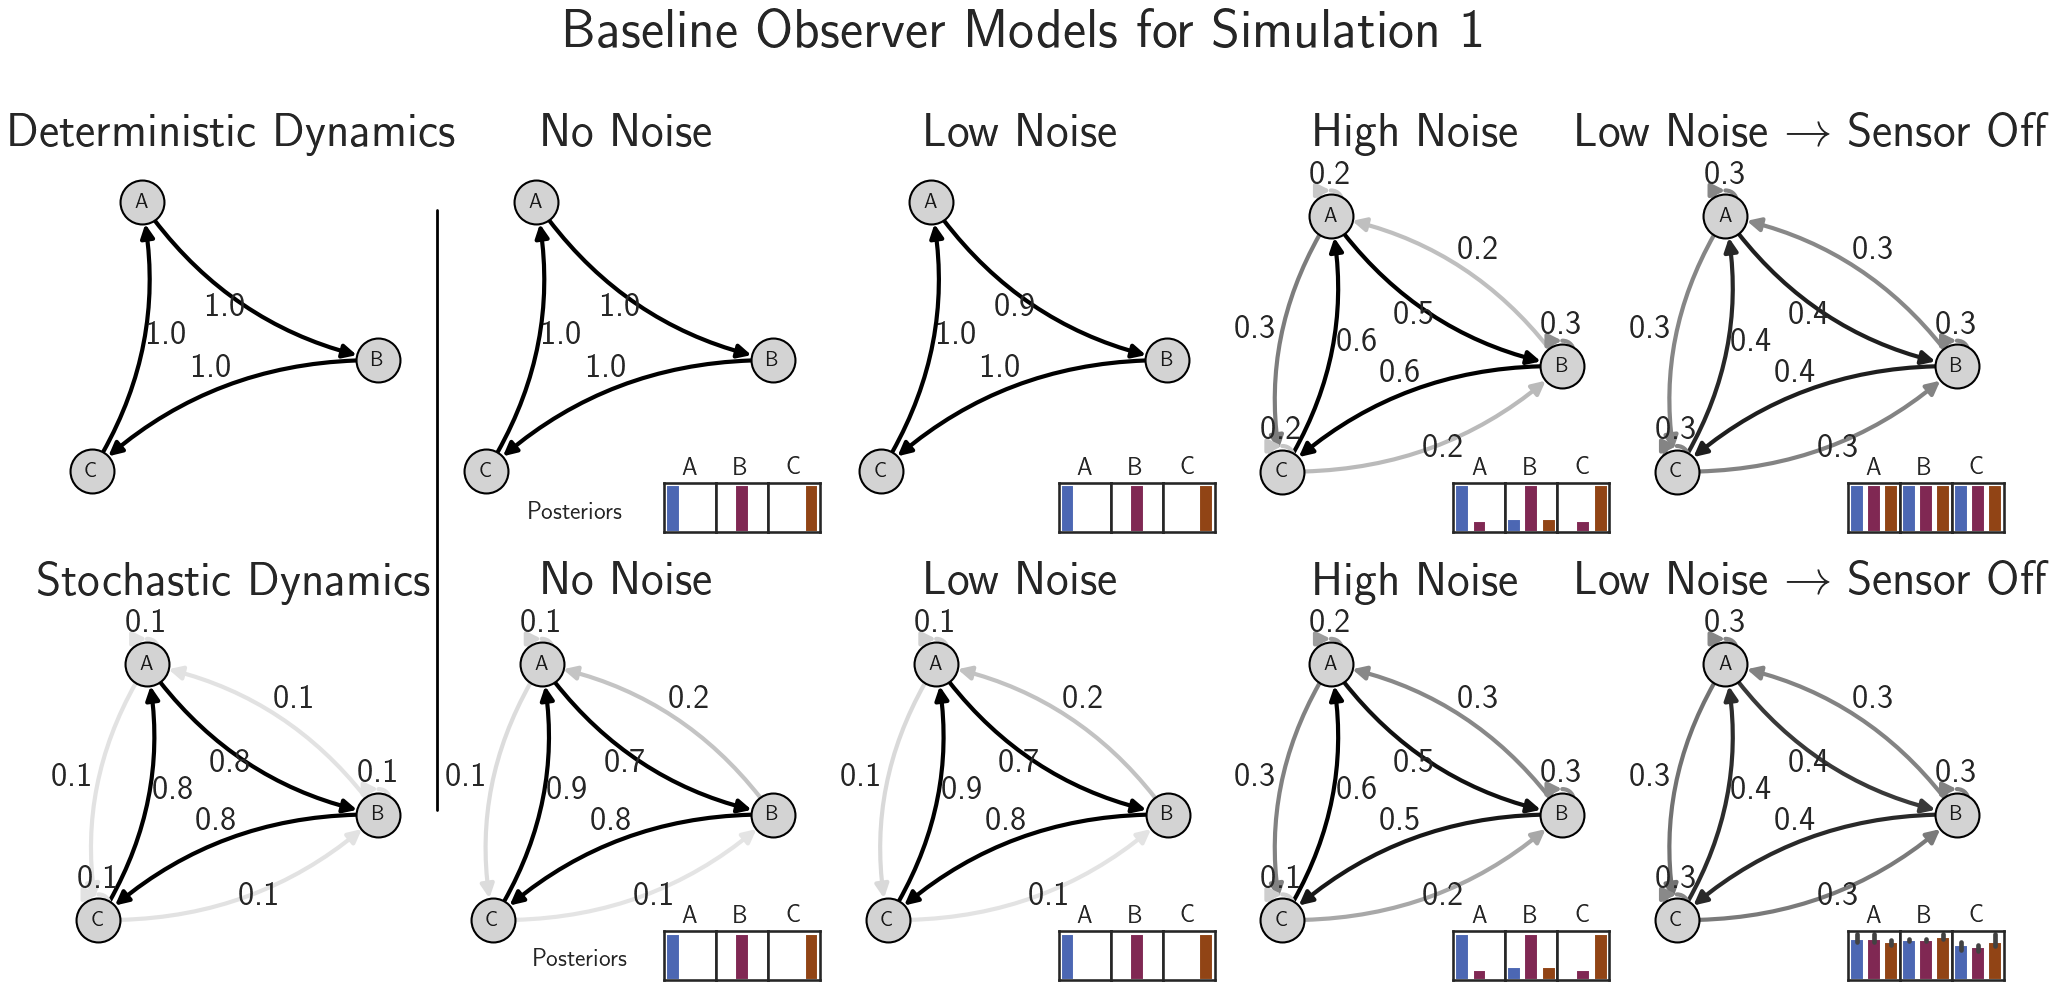

In [13]:
sns.set(style='white', context='talk')
ibm_palette = [ '#648fff', '#dc267f', '#fe6100', '#ffb000', '#785ef0', '#8be04e', '#009e73', '#56b4e9']
ibm_palette_darker = ['#3b5fc4','#8f1953','#a63f00','#a86f00','#4a37b8', '#8be04e', '#009e73', '#56b4e9']
sns.set_palette(ibm_palette_darker)

fig, ax = plt.subplots(2, 5, figsize=(5*4, 5*2))
fig.add_artist(plt.Line2D([0.205, 0.205], [0.2, 0.8], transform=fig.transFigure, color='black', linewidth=2, linestyle='-'))

i_half = len(deterministic_sequence)//2

thr = 0.05
states = ['A', 'B', 'C']
G_layout = nx.DiGraph()
G_layout.add_nodes_from(states)
pos = nx.spring_layout(G_layout, seed=42)

true_model = SLIM(dim, model_name='Deterministic Dynamics')
true_model.W = np.array([[0., 1., 0.],
                         [0., 0., 1.],
                         [1., 0., 0.]])

viz.create_digraph(true_model, states, ax[0][0], thr=thr)

viz.create_digraph(low_no_inference, states, ax[0][1], thr=thr)
plot_inset(ax[0][1], low_no_inference, deterministic_sequence)

viz.create_digraph(low_sensor_noise_no_inference, states, ax[0][2], thr=thr)
plot_inset(ax[0][2], low_sensor_noise_no_inference, deterministic_sequence)

viz.create_digraph(high_sensor_noise_no_inference, states, ax[0][3], thr=thr)
plot_inset(ax[0][3], high_sensor_noise_no_inference, deterministic_sequence)

viz.create_digraph(low_then_sensor_off_no_inference, states, ax[0][4], thr=thr)
plot_inset(ax[0][4], low_then_sensor_off_no_inference, deterministic_sequence)

####################### stochastic deterministic_sequence

true_model = SLIM(dim, model_name='Stochastic Dynamics')
true_model.W = stochastic_dynamics_matrix


viz.create_digraph(true_model, states, ax[1][0], thr=thr)

viz.create_digraph(low_process_noise_no_inference, states, ax[1][1], thr=thr)
plot_inset(ax[1][1], low_process_noise_no_inference, stochastic_sequence)

viz.create_digraph(low_process_and_sensor_noise_no_inference, states, ax[1][2], thr=thr)
plot_inset(ax[1][2], low_process_and_sensor_noise_no_inference, stochastic_sequence)

viz.create_digraph(high_process_and_sensor_noise_no_inference, states, ax[1][3], thr=thr)
plot_inset(ax[1][3], high_process_and_sensor_noise_no_inference, stochastic_sequence)

viz.create_digraph(low_process_then_sensor_off_no_inference, states, ax[1][4], thr=thr)
plot_inset(ax[1][4], low_process_then_sensor_off_fixed_W, stochastic_sequence)

ax[0][1].text(-.4,-1.2, 'Posteriors')
ax[1][1].text(-.4,-1.2, 'Posteriors')

# Noise Effect
plt.suptitle(r'Baseline Observer Models for Simulation 1', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/learned_dynamics_with_posteriors_no_inference.png', transparent=True, bbox_inches='tight')
plt.show()

###########################################

sns.set_palette(ibm_palette)


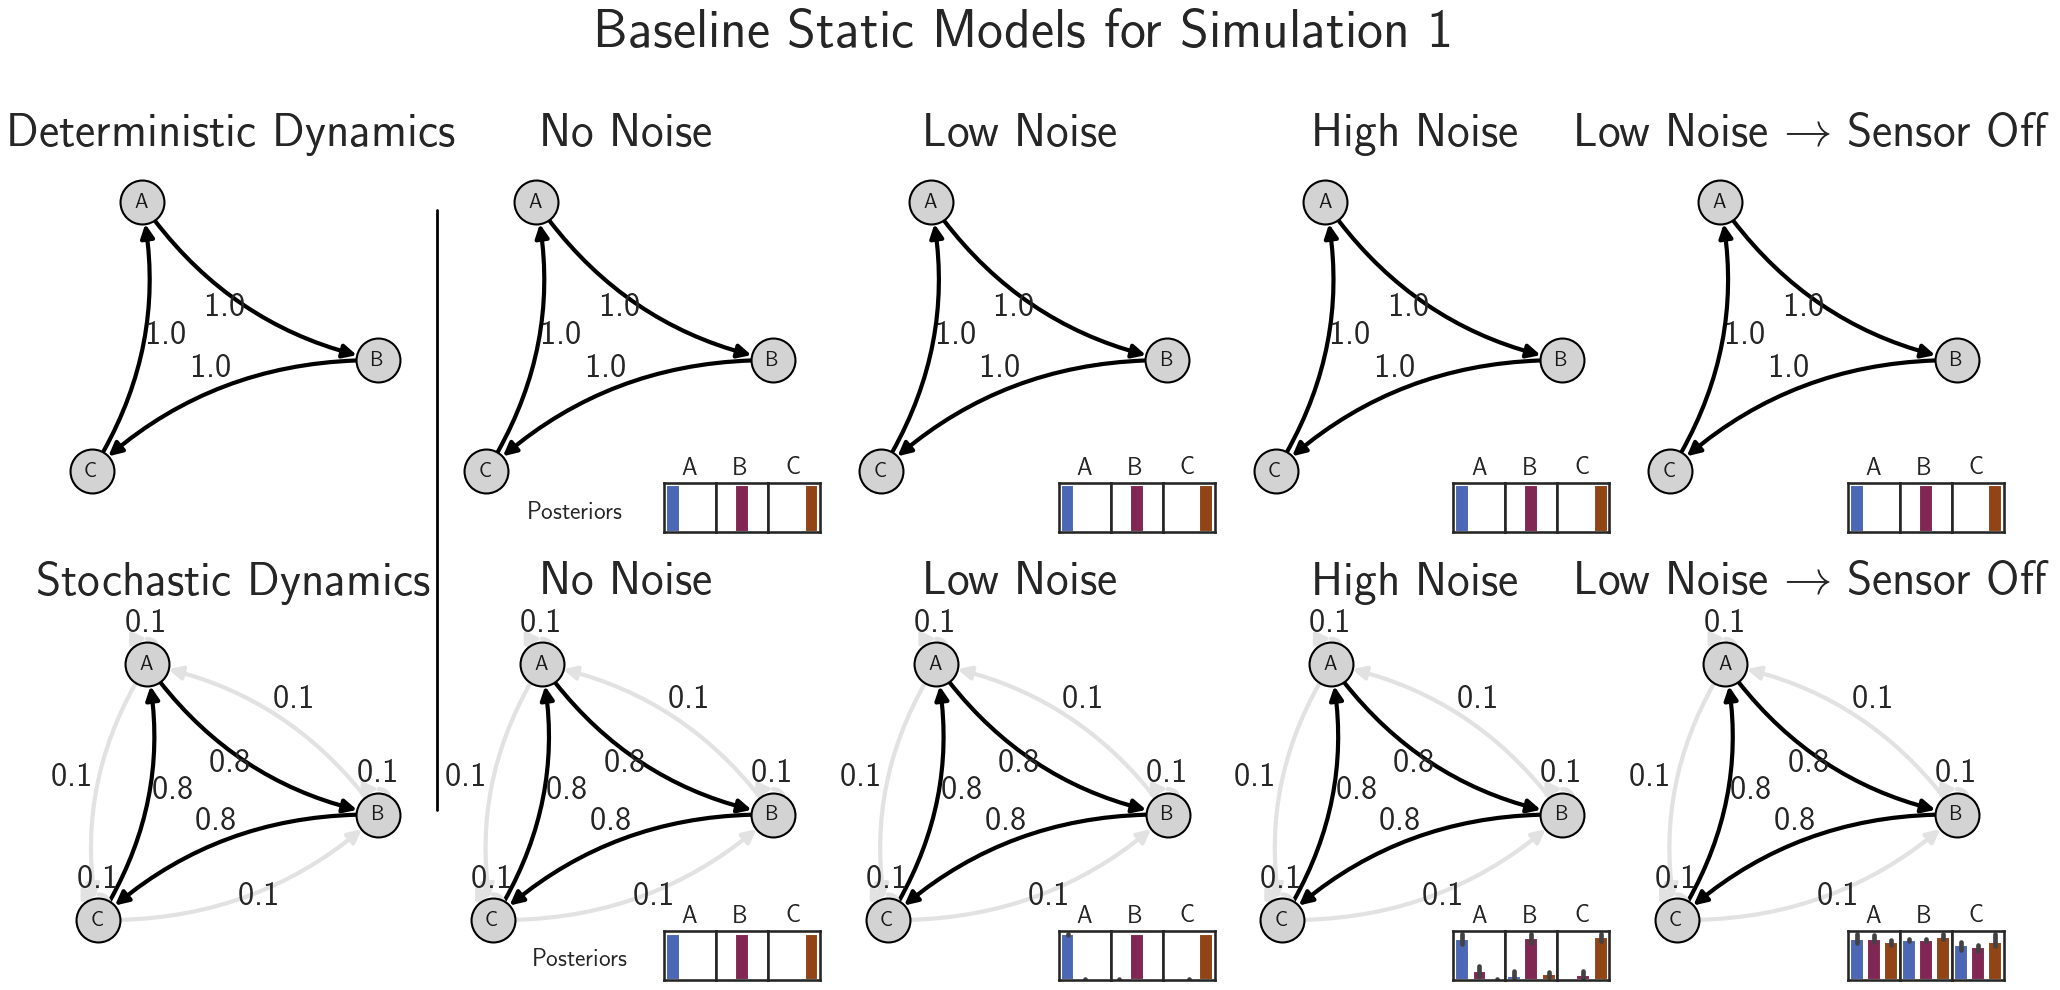

In [14]:
sns.set(style='white', context='talk')
ibm_palette = [ '#648fff', '#dc267f', '#fe6100', '#ffb000', '#785ef0', '#8be04e', '#009e73', '#56b4e9']
ibm_palette_darker = ['#3b5fc4','#8f1953','#a63f00','#a86f00','#4a37b8', '#8be04e', '#009e73', '#56b4e9']
sns.set_palette(ibm_palette_darker)

fig, ax = plt.subplots(2, 5, figsize=(5*4, 5*2))
fig.add_artist(plt.Line2D([0.205, 0.205], [0.2, 0.8], transform=fig.transFigure, color='black', linewidth=2, linestyle='-'))

i_half = len(deterministic_sequence)//2

thr = 0.05
states = ['A', 'B', 'C']
G_layout = nx.DiGraph()
G_layout.add_nodes_from(states)
pos = nx.spring_layout(G_layout, seed=42)

true_model = SLIM(dim, model_name='Deterministic Dynamics')
true_model.W = np.array([[0., 1., 0.],
                         [0., 0., 1.],
                         [1., 0., 0.]])

viz.create_digraph(true_model, states, ax[0][0], thr=thr)

viz.create_digraph(low_fixed_W, states, ax[0][1], thr=thr)
plot_inset(ax[0][1], low_fixed_W, deterministic_sequence)

viz.create_digraph(low_sensor_noise_fixed_W, states, ax[0][2], thr=thr)
plot_inset(ax[0][2], low_sensor_noise_fixed_W, deterministic_sequence)

viz.create_digraph(high_sensor_noise_fixed_W, states, ax[0][3], thr=thr)
plot_inset(ax[0][3], high_sensor_noise_fixed_W, deterministic_sequence)

viz.create_digraph(low_then_sensor_off_fixed_W, states, ax[0][4], thr=thr)
plot_inset(ax[0][4], low_then_sensor_off_fixed_W, deterministic_sequence)

####################### stochastic deterministic_sequence

true_model = SLIM(dim, model_name='Stochastic Dynamics')
true_model.W = stochastic_dynamics_matrix


viz.create_digraph(true_model, states, ax[1][0], thr=thr)

viz.create_digraph(low_process_noise_fixed_W, states, ax[1][1], thr=thr)
plot_inset(ax[1][1], low_process_noise_fixed_W, stochastic_sequence)

viz.create_digraph(low_process_and_sensor_noise_fixed_W, states, ax[1][2], thr=thr)
plot_inset(ax[1][2], low_process_and_sensor_noise_fixed_W, stochastic_sequence)

viz.create_digraph(high_process_and_sensor_noise_fixed_W, states, ax[1][3], thr=thr)
plot_inset(ax[1][3], high_process_and_sensor_noise_fixed_W, stochastic_sequence)

viz.create_digraph(low_process_then_sensor_off_fixed_W, states, ax[1][4], thr=thr)
plot_inset(ax[1][4], low_process_then_sensor_off_fixed_W, stochastic_sequence)

ax[0][1].text(-.4,-1.2, 'Posteriors')
ax[1][1].text(-.4,-1.2, 'Posteriors')

# Noise Effect
plt.suptitle(r'Baseline Static Models for Simulation 1', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/learned_dynamics_with_posteriors_fixed_W.png', transparent=True, bbox_inches='tight')
plt.show()

###########################################

sns.set_palette(ibm_palette)


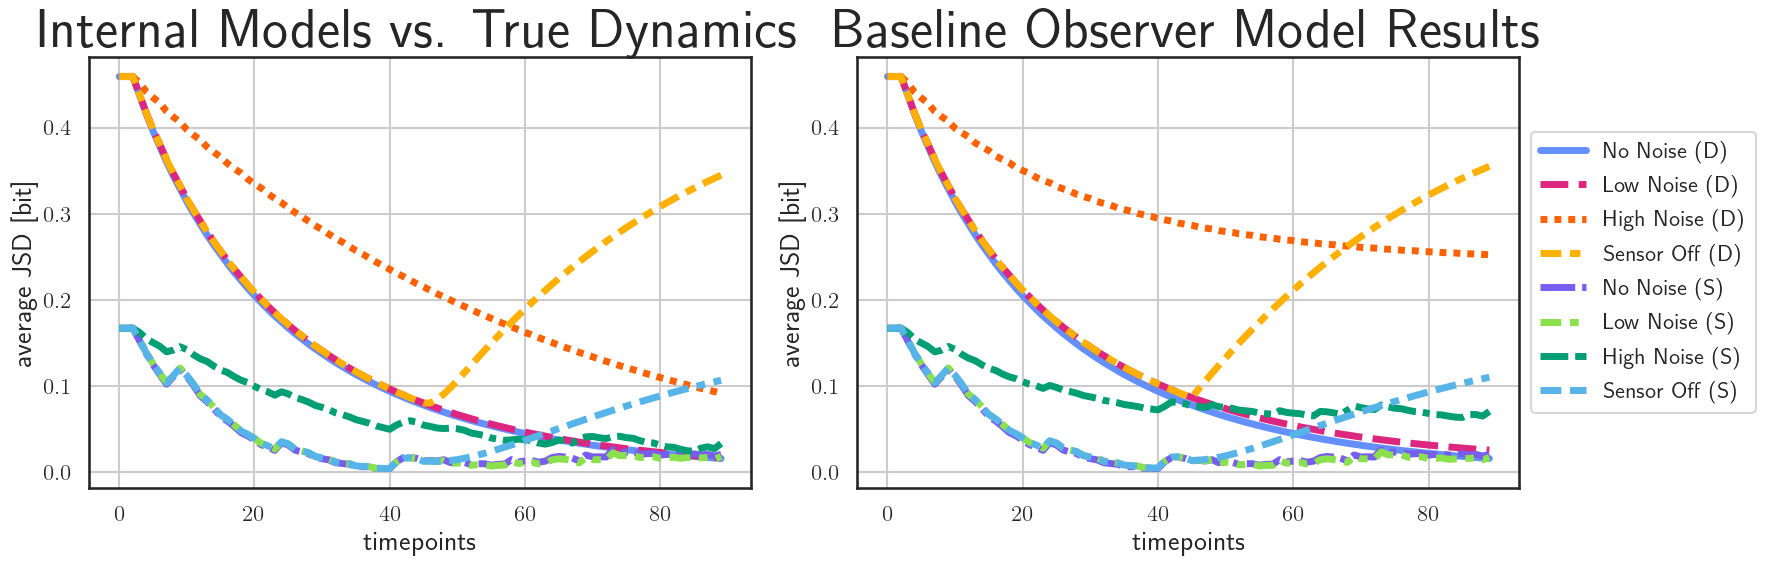

In [15]:
models = [
    [
        low,
        low_sensor_noise,
        high_sensor_noise,
        low_then_sensor_off,
        low_process_noise,
        low_process_and_sensor_noise,
        high_process_and_sensor_noise,
        low_process_then_sensor_off
    ],
    [
        low_no_inference,
        low_sensor_noise_no_inference,
        high_sensor_noise_no_inference,
        low_then_sensor_off_no_inference,
        low_process_noise_no_inference,
        low_process_and_sensor_noise_no_inference,
        high_process_and_sensor_noise_no_inference,
        low_process_then_sensor_off_no_inference
    ]
]

titles = ['Internal Models vs. True Dynamics', 'Baseline Observer Model Results']
columns = ['No Noise (D)','Low Noise (D)','High Noise (D)','Sensor Off (D)', 'No Noise (S)','Low Noise (S)','High Noise (S)','Sensor Off (S)']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, ax in enumerate(axes):

    simulation_1_jsd_results = np.array([
        [jsd_avg(W, gt) for W in m.W_hist]
        for gt, m in zip([deterministic_dynamics_matrix]*4 + [stochastic_dynamics_matrix]*4, models[idx])
    ]).T
    df = pd.DataFrame(simulation_1_jsd_results, columns=columns)

    ax.set_ylabel('average JSD [bit]', fontsize=20, fontweight='bold')
    ax.set_xlabel('timepoints', fontsize=20, fontweight='bold')
    sns.lineplot(df, linewidth=5, ax=ax)
    ax.set_title(titles[idx], fontweight='bold', fontsize=40, y=1.0)
    ax.legend().remove()
    ax.grid(True)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig('./results/simulation1_jsds_no_inference.png', transparent=True, bbox_inches='tight')
plt.show()

---

# Learning Nonstationary World Dynamics

---

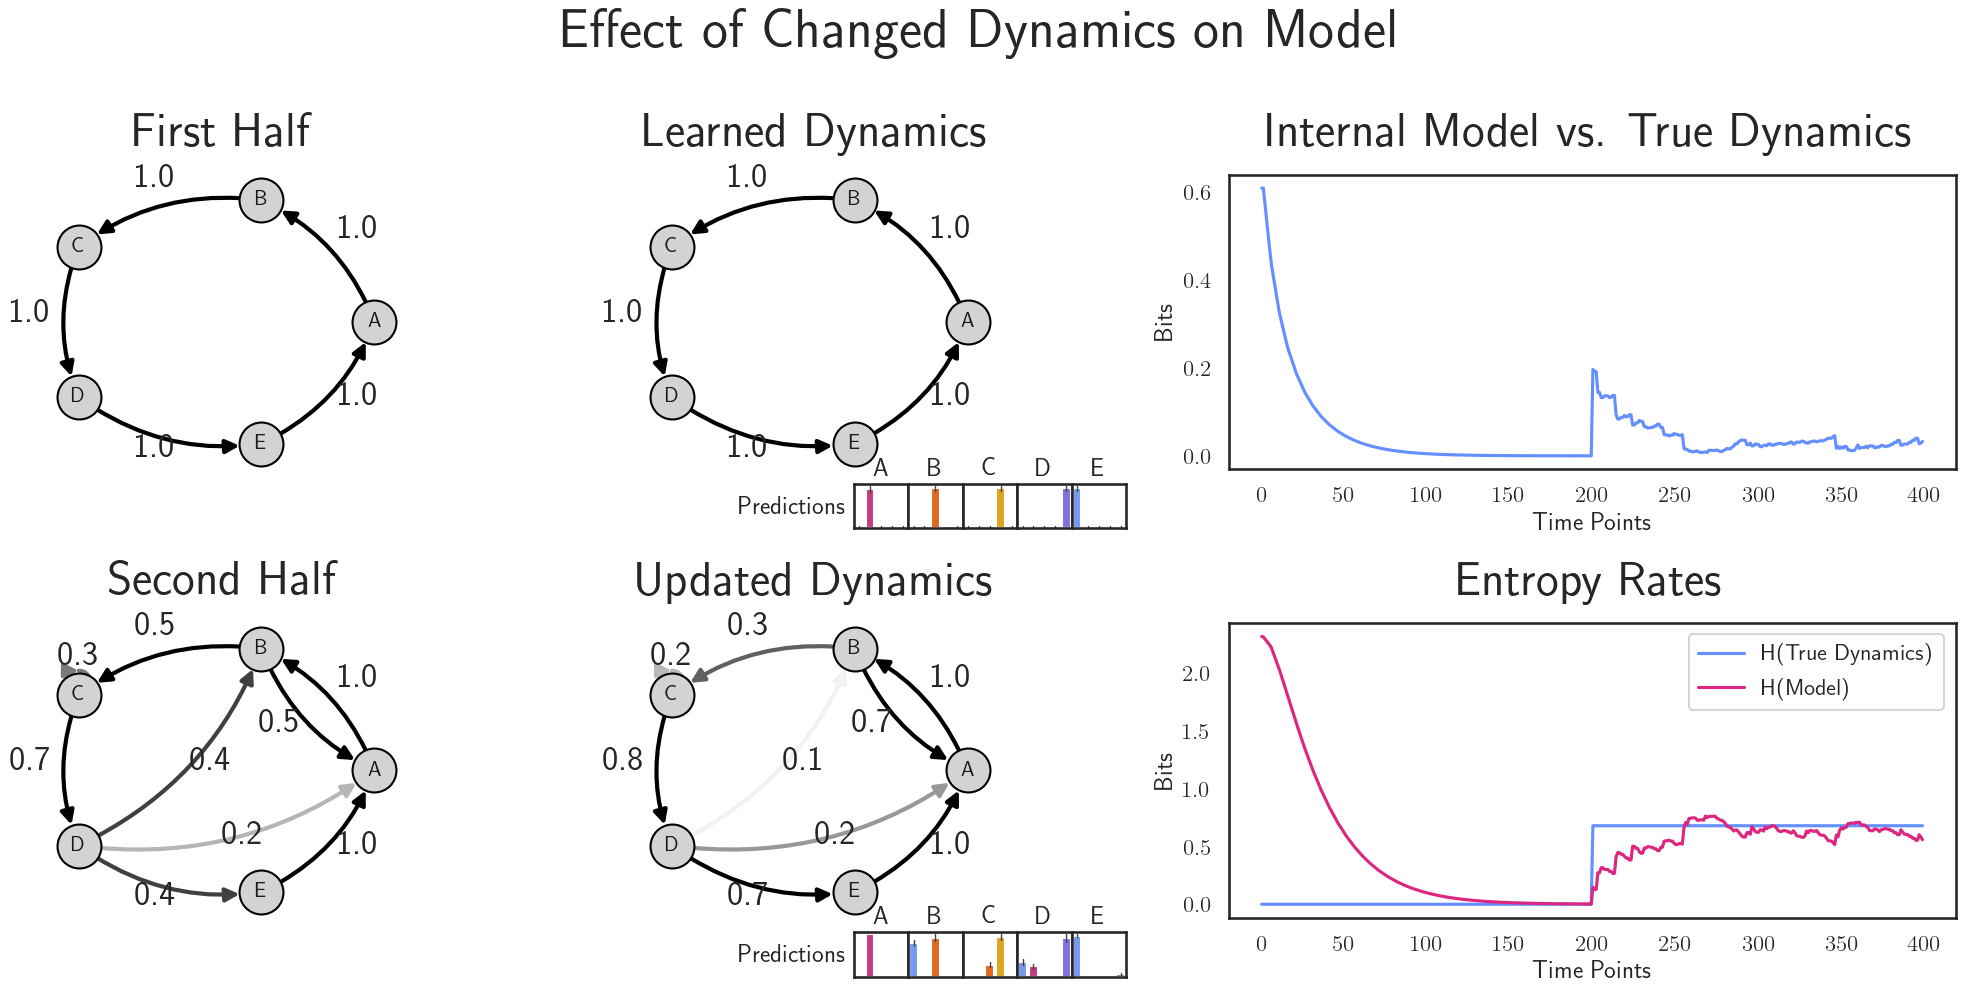

In [16]:
model = SLIM(dim=5, sensor=np.eye(5))
lr = 0.2
thr = 0.05

# fig, ax = plt.subplots(2, 3, figsize=(15,10))
fig = plt.figure(figsize=(20, 10))

gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 2], height_ratios=[1, 1])
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[1, 0])
ax4 = plt.subplot(gs[1, 1])
ax5 = plt.subplot(gs[0, 2])
ax6 = plt.subplot(gs[1, 2])

G_layout = nx.DiGraph()
states = ['A', 'B', 'C', 'D', 'E']
G_layout.add_nodes_from(states)
pos = nx.circular_layout(G_layout)


dynamics_first_half = np.array([[.0, 1., .0, .0, .0],
                                [.0, 0., 1., .0, .0],
                                [.0, 0., .0, 1., .0],
                                [.0, 0., .0, .0, 1.],
                                [1., 0., .0, .0, .0]])

dynamics_second_half = np.array([[.0, 1., .0, .0, .0],
                                [.5, .0, .5, .0, .0],
                                [.0, 0., .3, 0.7, .0],
                                [.2, .4, .0, 0., .4],
                                [1., 0., .0, .0, .0]])

# sample
sequence_first_half = [0]
for _ in range(200-1):
    dist = dynamics_first_half[sequence_first_half[-1]]
    sequence_first_half.append(np.random.choice(range(5), p=dist))
sequence_second_half = [sequence_first_half[-1]]
for _ in range(200-1):
    dist = dynamics_second_half[sequence_second_half[-1]]
    sequence_second_half.append(np.random.choice(range(5), p=dist))

########################### first half #################################################

placeholder = SLIM(dim=5, model_name='First Half')
placeholder.W = dynamics_first_half
viz.create_digraph(placeholder, states, ax1, thr=thr, pos=pos)

# model.fit(sequence_first_half, learning_rate=lr)
jsds = []
H_rates = []
for item in sequence_first_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_first_half, model.W))
    H_rates.append(entropy_rate(model.W))
    
model.model_name = 'Learned Dynamics'
viz.create_digraph(model, states, ax2, thr=thr, pos=pos)

##############
axins = ax2.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax2.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax2.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax2.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax2.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

########################### second half #################################################

placeholder = SLIM(dim=5, model_name='Second Half')
placeholder.W = dynamics_second_half
viz.create_digraph(placeholder, states, ax3, thr=thr, pos=pos)

model.model_name = 'Updated Dynamics'
# model.fit(sequence_second_half, learning_rate=lr)
for item in sequence_second_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_second_half, model.W))
    H_rates.append(entropy_rate(model.W))

viz.create_digraph(model, states, ax4, thr=thr, pos=pos)

# jsds
ax5.set_title('Internal Model vs. True Dynamics', fontweight='bold', fontsize=35, pad=20)
sns.lineplot(jsds, ax=ax5)
ax5.set_xlabel('Time Points')
ax5.set_ylabel('Bits')

# entropies

entropies_gt = np.concatenate([[entropy_rate(dynamics_first_half)]*len(sequence_first_half), [entropy_rate(dynamics_second_half)]*len(sequence_second_half)])

sns.lineplot(entropies_gt, ax=ax6, label='H(True Dynamics)')
sns.lineplot(H_rates, ax=ax6, label='H(Model)')
ax6.set_xlabel('Time Points')
ax6.set_ylabel('Bits')
ax6.set_title('Entropy Rates', fontweight='bold', fontsize=35, pad=20)


##############
i_half = len(sequence_first_half)
axins = ax4.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax4.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax4.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax4.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax4.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

ax2.text(-.4,-1.5, 'Predictions')
ax4.text(-.4,-1.5, 'Predictions')

plt.suptitle(r'Effect of Changed Dynamics on Model', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/updated_dynamics_with_predictions.png', transparent=True, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [17]:
dynamics_first_half = np.array([[.0, 1., .0, .0, .0],
                                [.0, 0., 1., .0, .0],
                                [.0, 0., .0, 1., .0],
                                [.0, 0., .0, .0, 1.],
                                [1., 0., .0, .0, .0]])

dynamics_second_half = np.array([[.0, 1., .0, .0, .0],
                                [.5, .0, .5, .0, .0],
                                [.0, 0., .3, 0.7, .0],
                                [.2, .4, .0, 0., .4],
                                [1., 0., .0, .0, .0]])

rng = np.random.default_rng(seed=42)

# sample
sequence_first_half = [0]
for _ in range(200-1):
    dist = dynamics_first_half[sequence_first_half[-1]]
    sequence_first_half.append(rng.choice(range(5), p=dist))
sequence_second_half = [sequence_first_half[-1]]
for _ in range(200-1):
    dist = dynamics_second_half[sequence_second_half[-1]]
    sequence_second_half.append(rng.choice(range(5), p=dist))


In [18]:

########################### first half ###################################

lr = 0.2
model = SLIM(dim=5, sensor=np.eye(5))

jsds = []
H_rates = []

for item in sequence_first_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_first_half, model.W))
    H_rates.append(entropy_rate(model.W))

########################### second half ###################################

jsds_dict = {}
H_rates_dict = {}
model_Ws = {}

# lrs = np.arange(0.001, 0.5, .001)
lrs = np.arange(0.0, 1., .01)
for lr in tqdm(lrs):
    model_clone = deepcopy(model)
    jsds_dict[lr] = []
    H_rates_dict[lr] = []
    model_Ws[lr] = []
    

    for item in sequence_second_half:
        model_clone.step(model_clone.observe(item, feed_observations=False), learning_rate=lr)
        del model_clone.x_hat_hist[-1]
        model_clone.predict()
        jsds_dict[lr].append(jsd_avg(dynamics_second_half, model_clone.W))
        H_rates_dict[lr].append(entropy_rate(model_clone.W))
        model_Ws[lr].append(model_clone.W)

  0%|          | 0/100 [00:00<?, ?it/s]

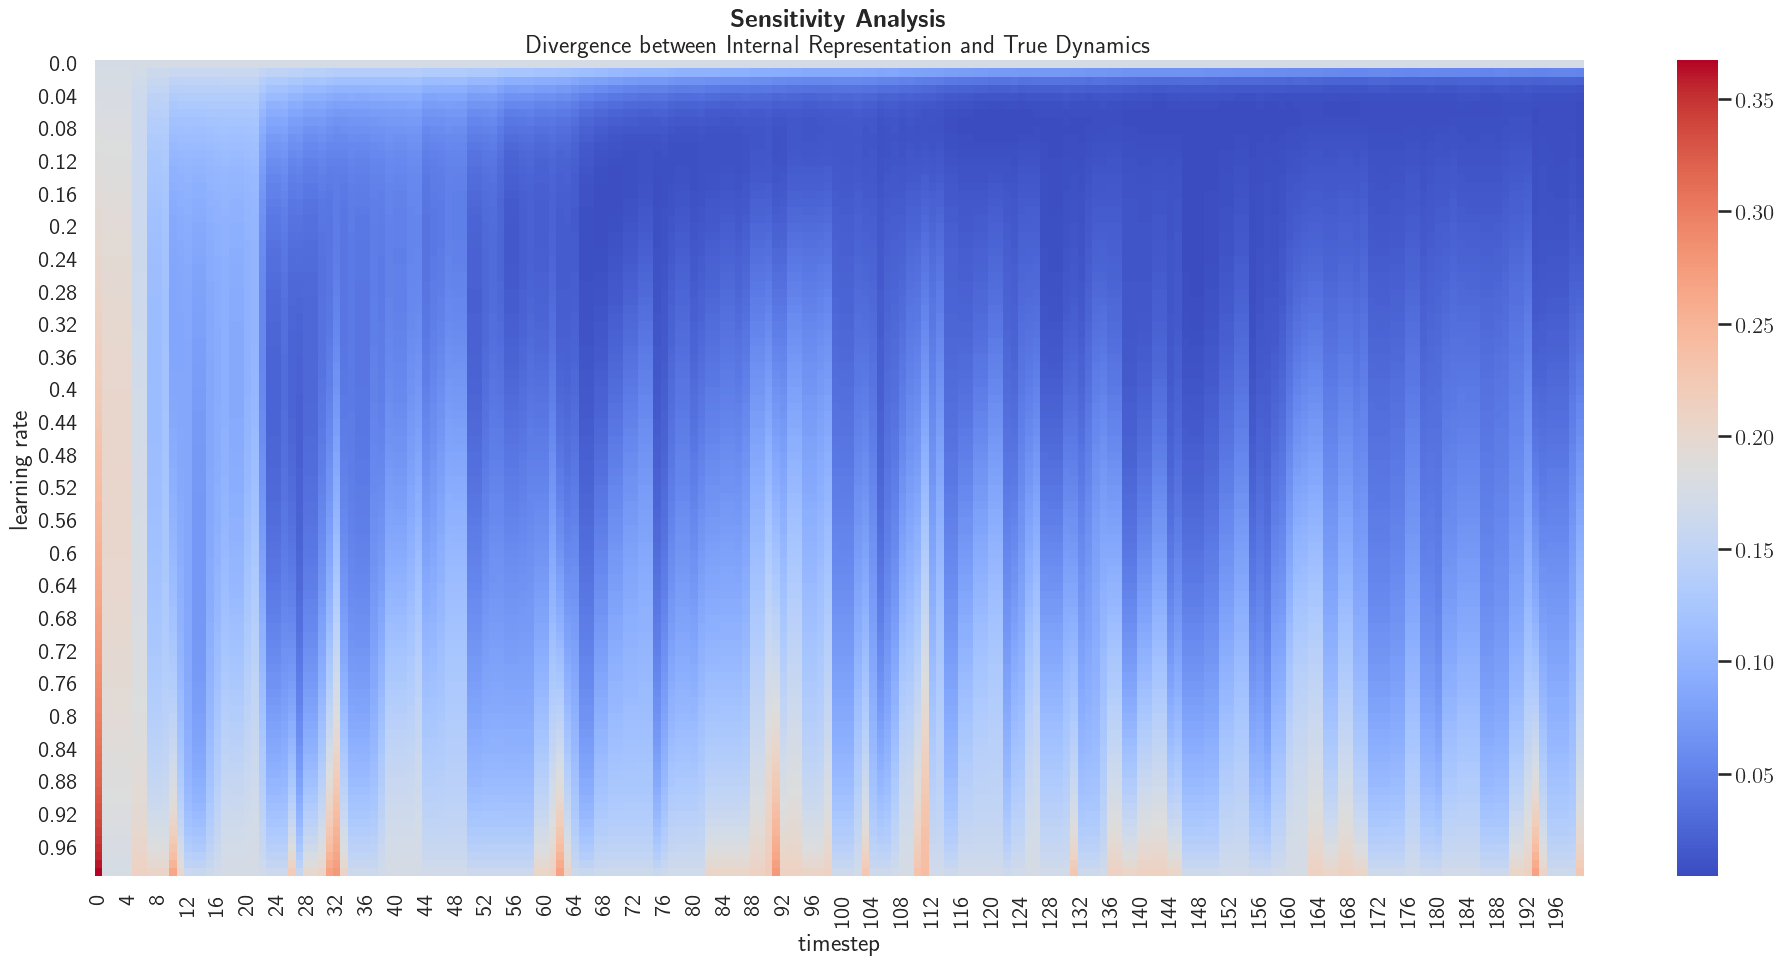

In [19]:
jsds_matrix = np.array(list(jsds_dict.values()))

plt.figure(figsize=(20,10))
ax = sns.heatmap(jsds_matrix, cmap='coolwarm')
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([np.round(lrs[int(t)], 2) for t in ticks], rotation=0)

plt.ylabel('learning rate')
plt.xlabel('timestep')
plt.title(r'$\textbf{Sensitivity Analysis}$' + '\nDivergence between Internal Representation and True Dynamics')
plt.tight_layout()
plt.show()

(100, 5, 5)


<Axes: >

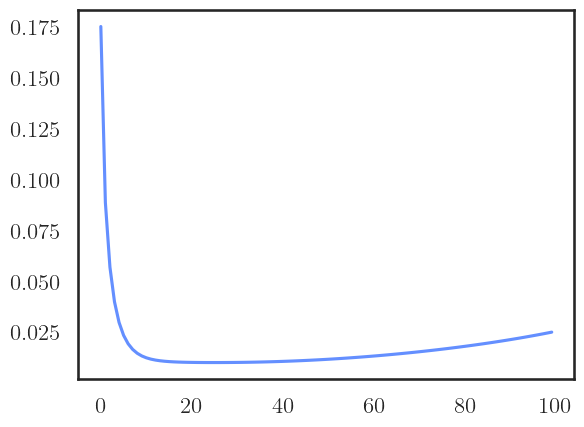

In [20]:
Ws_matrix = np.array(list(model_Ws.values()))
Ws_matrix = np.mean(Ws_matrix, axis=1)
print(Ws_matrix.shape)


# jsds_dict[lr].append(jsd_avg(dynamics_second_half, model_clone.W))
jsd_of_avg = np.array([jsd_avg(dynamics_second_half, W) for W in Ws_matrix])
sns.lineplot(jsd_of_avg)

In [21]:
sum_jsds = np.nansum(jsds_matrix, axis=1)
avg_jsds = np.nanmean(jsds_matrix, axis=1)

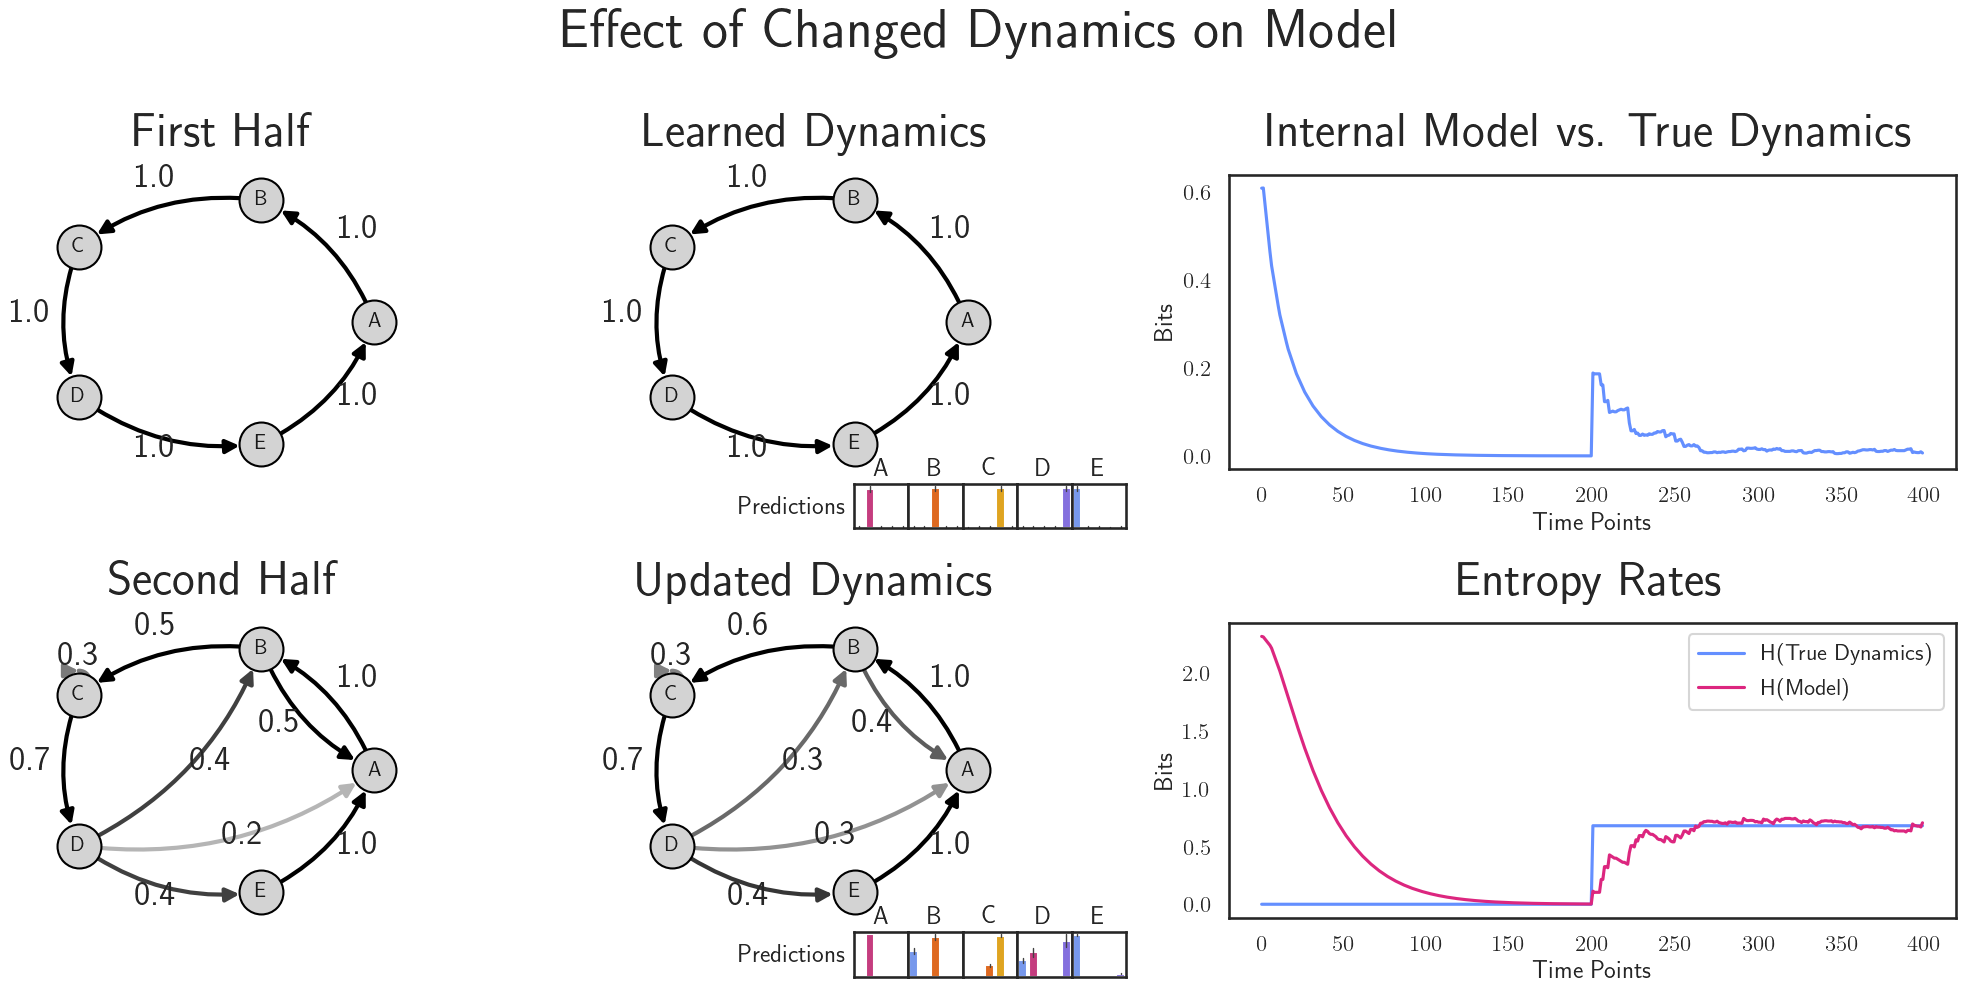

In [22]:
model = SLIM(dim=5, sensor=np.eye(5))
lr = 0.2

# fig, ax = plt.subplots(2, 3, figsize=(15,10))
fig = plt.figure(figsize=(20, 10))

gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 2], height_ratios=[1, 1])
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[1, 0])
ax4 = plt.subplot(gs[1, 1])
ax5 = plt.subplot(gs[0, 2])
ax6 = plt.subplot(gs[1, 2])

G_layout = nx.DiGraph()
states = ['A', 'B', 'C', 'D', 'E']
G_layout.add_nodes_from(states)
pos = nx.circular_layout(G_layout)

########################### first half #################################################

placeholder = SLIM(dim=5, model_name='First Half')
placeholder.W = dynamics_first_half
viz.create_digraph(placeholder, states, ax1, thr=thr, pos=pos)

# model.fit(sequence_first_half, learning_rate=lr)
jsds = []
H_rates = []
for item in sequence_first_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_first_half, model.W))
    H_rates.append(entropy_rate(model.W))
    
model.model_name = 'Learned Dynamics'
viz.create_digraph(model, states, ax2, thr=thr, pos=pos)

##############
axins = ax2.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax2.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax2.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax2.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax2.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[np.array(sequence_first_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

########################### second half #################################################

lr = lrs[np.argmin(sum_jsds)]

placeholder = SLIM(dim=5, model_name='Second Half')
placeholder.W = dynamics_second_half
viz.create_digraph(placeholder, states, ax3, thr=thr, pos=pos)

model.model_name = 'Updated Dynamics'
# model.fit(sequence_second_half, learning_rate=lr)
for item in sequence_second_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_second_half, model.W))
    H_rates.append(entropy_rate(model.W))

viz.create_digraph(model, states, ax4, thr=thr, pos=pos)

# jsds
ax5.set_title('Internal Model vs. True Dynamics', fontweight='bold', fontsize=35, pad=20)
sns.lineplot(jsds, ax=ax5)
ax5.set_xlabel('Time Points')
ax5.set_ylabel('Bits')

# entropies

entropies_gt = np.concatenate([[entropy_rate(dynamics_first_half)]*len(sequence_first_half), [entropy_rate(dynamics_second_half)]*len(sequence_second_half)])

sns.lineplot(entropies_gt, ax=ax6, label='H(True Dynamics)')
sns.lineplot(H_rates, ax=ax6, label='H(Model)')
ax6.set_xlabel('Time Points')
ax6.set_ylabel('Bits')
ax6.set_title('Entropy Rates', fontweight='bold', fontsize=35, pad=20)


##############
i_half = len(sequence_first_half)
axins = ax4.inset_axes([0.1+0.5, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==0], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('A')
axins = ax4.inset_axes([0.1+0.65, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==1], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('B')
axins = ax4.inset_axes([0.1+0.8, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==2], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('C')
axins = ax4.inset_axes([0.1+0.95, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==3], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('D')
axins = ax4.inset_axes([0.1+1.1, -0.2, 0.15, 0.15])
sns.barplot(np.array(model.x_hat_hist)[i_half:][np.array(sequence_second_half)==4], ax=axins, err_kws={"linewidth": 1})
axins.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axins.set_title('E')

ax2.text(-.4,-1.5, 'Predictions')
ax4.text(-.4,-1.5, 'Predictions')

plt.suptitle(r'Effect of Changed Dynamics on Model', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/updated_dynamics_with_predictions.png', transparent=True, bbox_inches='tight')

plt.tight_layout()
plt.show()

# do AUC

take 3 points: optimal, two others 
show entropy comparison between the three points

In [23]:
model = SLIM(dim=5, sensor=np.eye(5))
lr = 0.2

jsds = []
H_rates = []
for item in sequence_first_half:
    model.step(model.observe(item, feed_observations=False), learning_rate=lr)
    del model.x_hat_hist[-1]
    model.predict()
    jsds.append(jsd_avg(dynamics_first_half, model.W))
    H_rates.append(entropy_rate(model.W))

########################### second half #################################################

lr = lrs[np.argmin(sum_jsds)]
model_copy = deepcopy(model)
H_rates_copy0 = deepcopy(H_rates)
jsds_copy0 = deepcopy(jsds)

for item in sequence_second_half:
    model_copy.step(model_copy.observe(item, feed_observations=False), learning_rate=lr)
    del model_copy.x_hat_hist[-1]
    model_copy.predict()
    jsds_copy0.append(jsd_avg(dynamics_second_half, model_copy.W))
    H_rates_copy0.append(entropy_rate(model_copy.W))

lr_idx = 2
lr = lrs[lr_idx]
model_copy = deepcopy(model)
H_rates_copy1 = deepcopy(H_rates)
jsds_copy1 = deepcopy(jsds)

for item in sequence_second_half:
    model_copy.step(model_copy.observe(item, feed_observations=False), learning_rate=lr)
    del model_copy.x_hat_hist[-1]
    model_copy.predict()
    jsds_copy1.append(jsd_avg(dynamics_second_half, model_copy.W))
    H_rates_copy1.append(entropy_rate(model_copy.W))

lr_idx = 90
lr = lrs[lr_idx]
model_copy = deepcopy(model)
H_rates_copy2 = deepcopy(H_rates)
jsds_copy2 = deepcopy(jsds)

for item in sequence_second_half:
    model_copy.step(model_copy.observe(item, feed_observations=False), learning_rate=lr)
    del model_copy.x_hat_hist[-1]
    model_copy.predict()
    jsds_copy2.append(jsd_avg(dynamics_second_half, model_copy.W))
    H_rates_copy2.append(entropy_rate(model_copy.W))

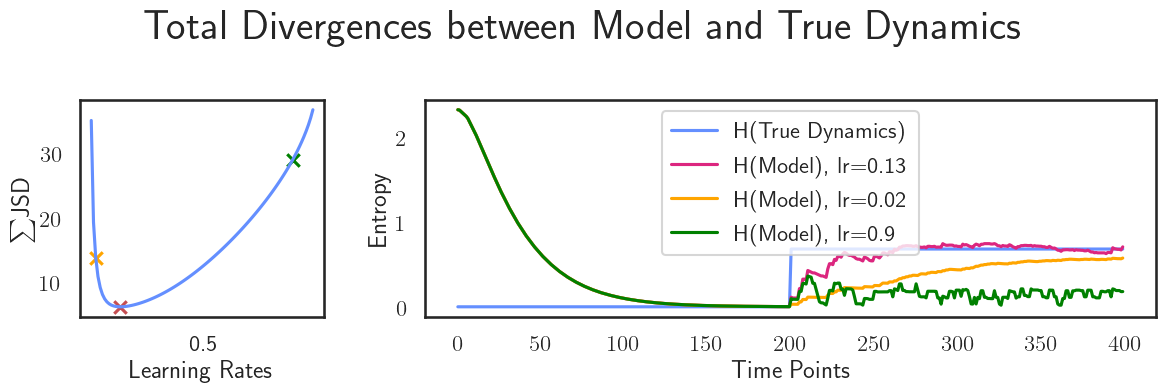

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'width_ratios': [1,3]})
sum_jsds = np.nansum(jsds_matrix, axis=1)
sns.lineplot(sum_jsds, ax=ax[0])
ticks = ax[0].get_xticks()
ax[0].set_xticks(ticks)
ax[0].set_xticklabels([np.round(lrs[int(tick)],2) if tick>0 and tick<len(lrs) else '' for tick in ticks])
ax[0].set_xlabel('Learning Rates')
ax[0].set_ylabel(r'$\sum$JSD')

ax[0].scatter(np.argmin(sum_jsds),np.min(sum_jsds), c='r', marker='x')  # global min
lr_idx = 2
ax[0].scatter(lr_idx,sum_jsds[lr_idx], c='orange', marker='x')  # global min
lr_idx = 90
ax[0].scatter(lr_idx,sum_jsds[lr_idx], c='green', marker='x')  # global min

##
sns.lineplot(entropies_gt, label='H(True Dynamics)', ax=ax[1])
sns.lineplot(H_rates_copy0, label=f'H(Model), lr={lrs[np.argmin(sum_jsds)]}', ax=ax[1])
sns.lineplot(H_rates_copy1, label=f'H(Model), lr={lrs[2]}', ax=ax[1], c='orange')
sns.lineplot(H_rates_copy2, label=f'H(Model), lr={lrs[90]}', ax=ax[1], c='green')
ax[1].set_ylabel('Entropy')
ax[1].set_xlabel('Time Points')

plt.suptitle(r'Total Divergences between Model and True Dynamics', fontweight='bold', fontsize=30, y=1.0)
plt.tight_layout()

plt.show()


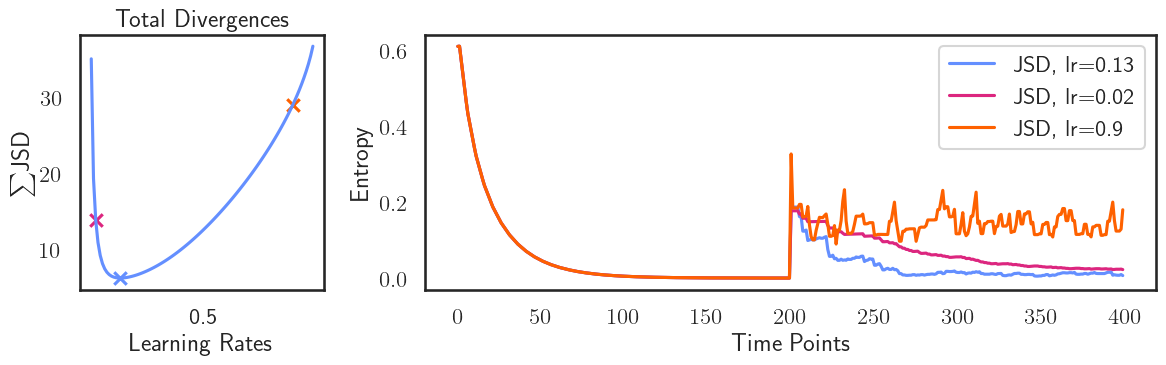

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'width_ratios': [1,3]})
sum_jsds = np.nansum(jsds_matrix, axis=1)
sns.lineplot(sum_jsds, ax=ax[0])
ticks = ax[0].get_xticks()
ax[0].set_xticks(ticks)
ax[0].set_xticklabels([np.round(lrs[int(tick)],2) if tick>0 and tick<len(lrs) else '' for tick in ticks])
ax[0].set_xlabel('Learning Rates')
ax[0].set_ylabel(r'$\sum$JSD')
ax[0].set_title('Total Divergences')

ax[0].scatter(np.argmin(sum_jsds),np.min(sum_jsds), c=ibm_palette[0], marker='x')  # global min
lr_idx = 2
ax[0].scatter(lr_idx,sum_jsds[lr_idx], c=ibm_palette[1], marker='x')  # global min
lr_idx = 90
ax[0].scatter(lr_idx,sum_jsds[lr_idx], c=ibm_palette[2], marker='x')  # global min

##
sns.lineplot(jsds_copy0, label=f'JSD, lr={lrs[np.argmin(sum_jsds)]}', ax=ax[1], c=ibm_palette[0])
sns.lineplot(jsds_copy1, label=f'JSD, lr={lrs[2]}', ax=ax[1], c=ibm_palette[1])
sns.lineplot(jsds_copy2, label=f'JSD, lr={lrs[90]}', ax=ax[1], c=ibm_palette[2])
ax[1].set_ylabel('Entropy')
ax[1].set_xlabel('Time Points')

plt.tight_layout()
plt.show()


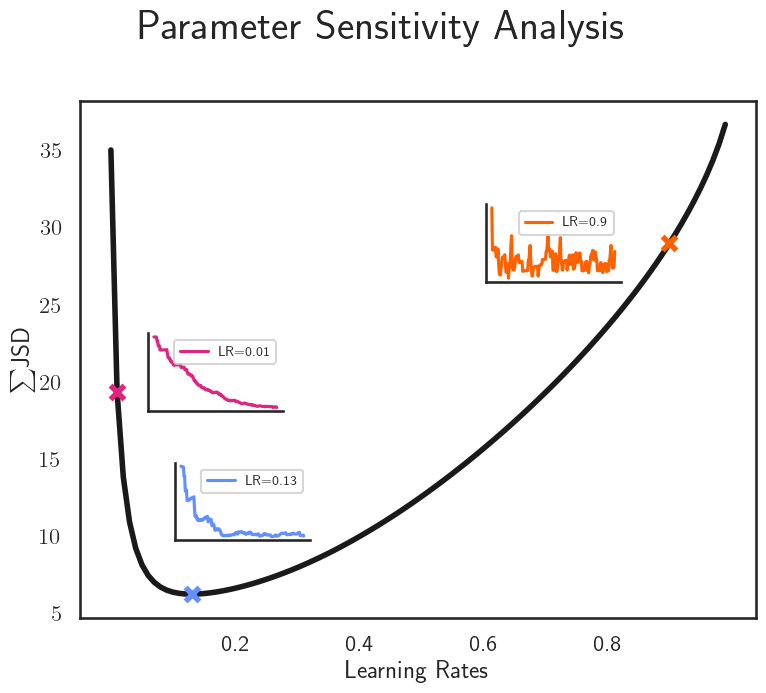

In [26]:
fig = plt.figure(figsize=(8,7))

ax = sns.lineplot(sum_jsds, c='k', linewidth=4)
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([np.round(lrs[int(tick)],2) if tick>0 and tick<len(lrs) else '' for tick in ticks])
ax.set_xlabel('Learning Rates')
ax.set_ylabel(r'$\sum$JSD')

ax.scatter(np.argmin(sum_jsds),np.min(sum_jsds), c=ibm_palette[0], linewidth=4, zorder=2, marker='x', s=100)  # global min
lr_idx_1 = 1
ax.scatter(lr_idx_1,sum_jsds[lr_idx_1], c=ibm_palette[1], linewidth=4, zorder=2, marker='x', s=100)  # global min
lr_idx_2 = 90
ax.scatter(lr_idx_2,sum_jsds[lr_idx_2], c=ibm_palette[2], linewidth=4, zorder=2, marker='x', s=100)  # global min

axins = ax.inset_axes([0.14, .15, 0.2, 0.15])
axins.set_xticks([])
axins.set_yticks([])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)
sns.lineplot(jsds_copy0[200:], label=f'LR={lrs[np.argmin(sum_jsds)]}', c=ibm_palette[0], ax=axins)
axins.legend(fontsize=10)

axins = ax.inset_axes([0.1, .4, 0.2, 0.15])
axins.set_xticks([])
axins.set_yticks([])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)
sns.lineplot(jsds_copy1[200:], label=f'LR={lrs[lr_idx_1]}', c=ibm_palette[1], ax=axins)
axins.legend(fontsize=10)

axins = ax.inset_axes([0.6, .65, 0.2, 0.15])
axins.set_xticks([])
axins.set_yticks([])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)
sns.lineplot(jsds_copy2[200:], label=f'LR={lrs[lr_idx_2]}', c=ibm_palette[2], ax=axins)
axins.legend(fontsize=10)


plt.suptitle(r'Parameter Sensitivity Analysis', fontweight='bold', fontsize=30, y=1.0)
# +'\nModel vs. True Dynamics Divergences'
plt.tight_layout()

plt.savefig('./results/parameter_sensitivity_analysis.png', transparent=True, bbox_inches='tight')

plt.show()


---

# Local-Global Paradigm

---

### Define Sequence

In [27]:
sequence = [0,0,0,1]*100

# inject 3 local-standard global-deviants
sequence[363] = 0
sequence[383] = 0
sequence[391] = 0

### Train Hierarchical Model

In [28]:
state_dim = 2
sensor = np.eye(state_dim)

learning_rate = 0.02

# model definitions
local_level = SLIM(order=1, track_dyn=True, verbose=False, feedback_from_levels=[3], dim=state_dim, sensor=np.eye(state_dim), model_name='1st Order Dynamics')
global_level = SLIM(order=3, track_dyn=True, verbose=False, feedforward_from_levels=[1], dim=state_dim, sensor=np.eye(state_dim), model_name='3rd Order Dynamics')

x_hat_global_level = np.ones(state_dim)/state_dim  # set first feedback as uninformative (uniform)

loop = tqdm(sequence)
for x in loop:
    y = local_level.observe(x)
    x_tilde_local_level = local_level.step(y, fb_prediction=x_hat_global_level, learning_rate=learning_rate)
    x_hat_global_level = global_level.step(x_tilde_local_level, learning_rate=learning_rate)

  0%|          | 0/400 [00:00<?, ?it/s]

	 Warning, model <3rd Order Dynamics> got no measurement, initializing with a uniform distribution.


### Plot Hierarchical Prediction Errors

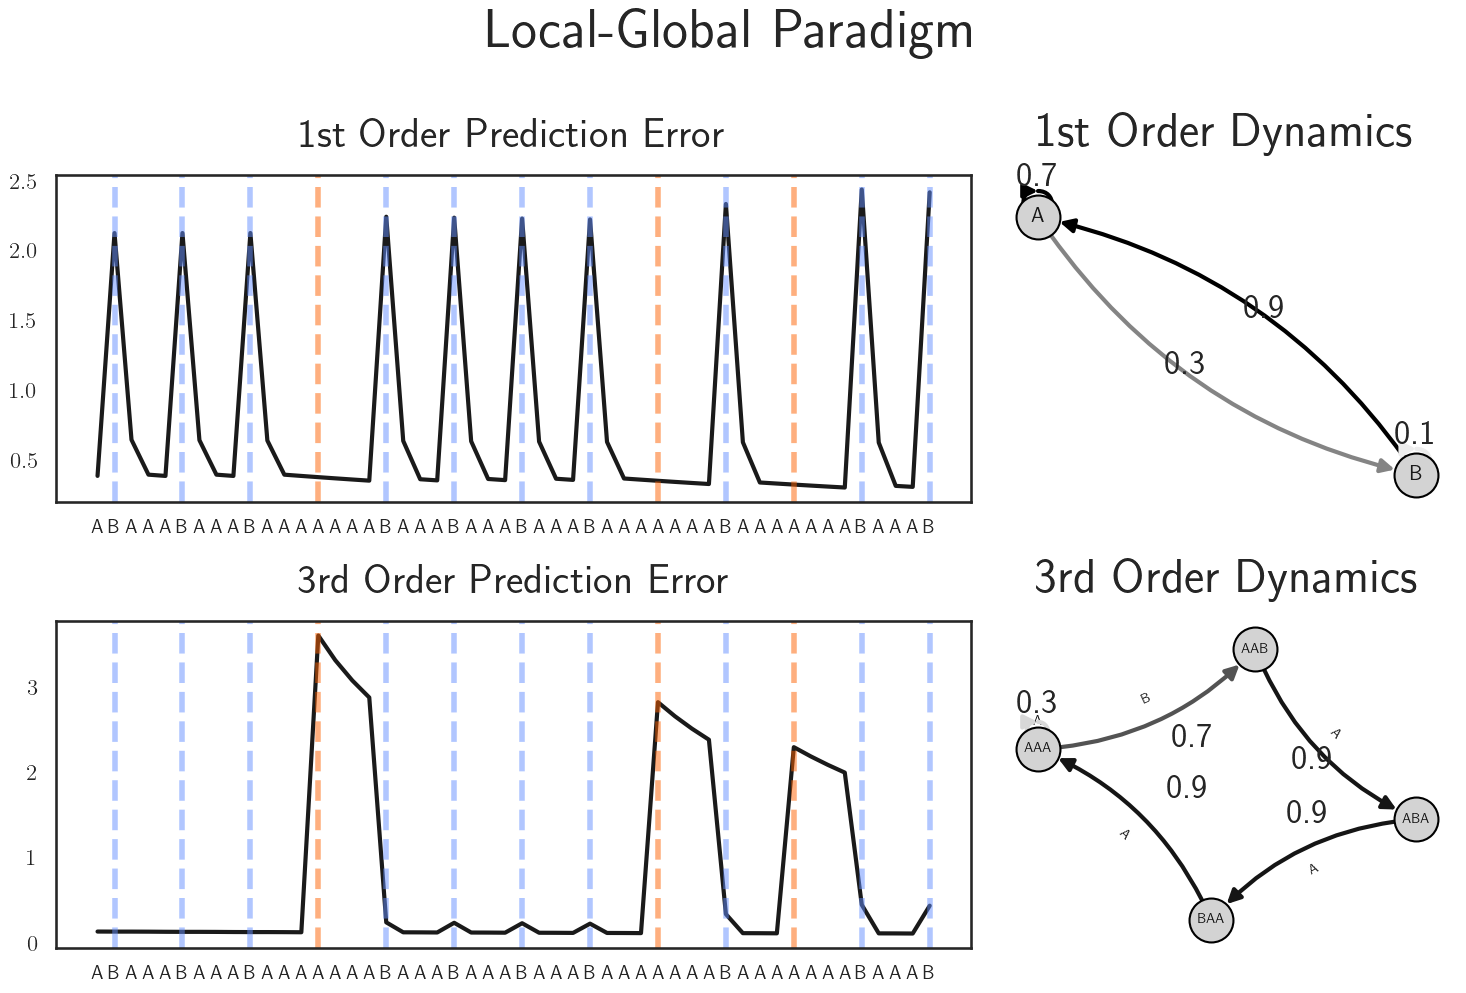

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(5*3, 5*2))

thr = 0.05

gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[1, 0])
ax4 = plt.subplot(gs[1, 1])

states = ['A', 'B']

last = 50

sns.lineplot(np.array(local_level.bayesian_surprise_hist)[-last:], ax=ax1, c='k', linewidth=3)
ax1.set_title('1st Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax1.set_xticks(np.arange(last), [states[elem] for elem in sequence[-last:]], fontweight='bold', fontsize=14)
        
sns.lineplot(np.array(global_level.bayesian_surprise_hist)[-last:], ax=ax3, c='k', linewidth=3)
ax3.set_title('3rd Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax3.set_xticks(np.arange(last), [states[elem] for idx,elem in enumerate(sequence[-last:])], fontweight='bold', fontsize=14)

local_errors = [0 if elem==0 else 1 for elem in sequence[-last:]]
for idx, err in enumerate(local_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)

global_errors = [1 if idx>2 and sum(sequence[-last:][idx-3:idx+4])==0 else 0 for idx,elem in enumerate(sequence[-last:])]
for idx, err in enumerate(global_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)


################################################################################################################
        
viz.create_digraph(model=local_level, states=['A', 'B'], axis=ax2, thr=thr)

################################################################################################################

G = nx.DiGraph()
edges = [
    ('AAA', 'AAA', 'A'),
    ('AAA', 'AAB', 'B'),
    ('AAB', 'ABA', 'A'),
    ('ABA', 'BAA', 'A'),
    ('BAA', 'AAA', 'A'),
]

edge_labels_code = {
    ('AAA', 'AAA'): 'A',
    ('AAA', 'AAB'): 'B',
    ('AAB', 'ABA'): 'A',
    ('ABA', 'BAA'): 'A',
    ('BAA', 'AAA'): 'A'
}

weights = [global_level.W[0][0], global_level.W[0][1], global_level.W[1][0], global_level.W[2][0], global_level.W[2][0]]

for idx, (u, v, label) in enumerate(edges):
    G.add_edge(u, v, label=label, weight=weights[idx])
    
pos = nx.spring_layout(G)

# edge_labels = nx.get_edge_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'weight')
norm = mcolors.Normalize(vmin=0., vmax=1.)
cmap = plt.cm.Greys
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_colors = [cmap(norm(G[u][v]['weight'])) for u, v in G.edges()]

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_code)

nx.draw(G, pos, with_labels=True, node_size=1000, node_color='lightgray', font_size=10, font_weight='bold',
        arrows=True, edgecolors='black', edge_color=edge_colors, connectionstyle='arc3,rad=0.2', arrowsize=20, width=3)

for (u, v), w in edge_labels.items():
    if w > thr:
        if u != v:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            dx, dy = x2 - x1, y2 - y1
            perp_offset = -0.3  # Increase for more distance from edge
            norm = np.sqrt(dx**2 + dy**2)
            ox, oy = -dy / norm * perp_offset, dx / norm * perp_offset
            ax4.text(mx + ox, my + oy, f"{w:.1f}", fontsize=25, bbox=dict(facecolor='none', edgecolor='none')) #, alpha=0.0))
        else:
            x, y = pos[u]
            ax4.text(x, y + 0.25, f"{w:.1f}", fontsize=25, va='center', ha='center', bbox=dict(facecolor='none', edgecolor='none')) #, alpha=0.6))
for node in states:
    if G.has_edge(node, node):
        x, y = pos[node]
        offset = 0.2
        ax4.add_patch(FancyArrowPatch((x + offset, y + offset), (x + offset, y + offset), connectionstyle="arc3,rad=0.5",  arrowstyle='->', arrowsize=20, mutation_scale=20, color='black', lw=1.5))
        
ax4.axis('off')
ax4.set_title(global_level.model_name, fontweight='bold', fontsize=35, pad=20)

for ax in ax.ravel():
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Local-Global Paradigm', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/local_global_paradigm.png', transparent=True)
plt.show()


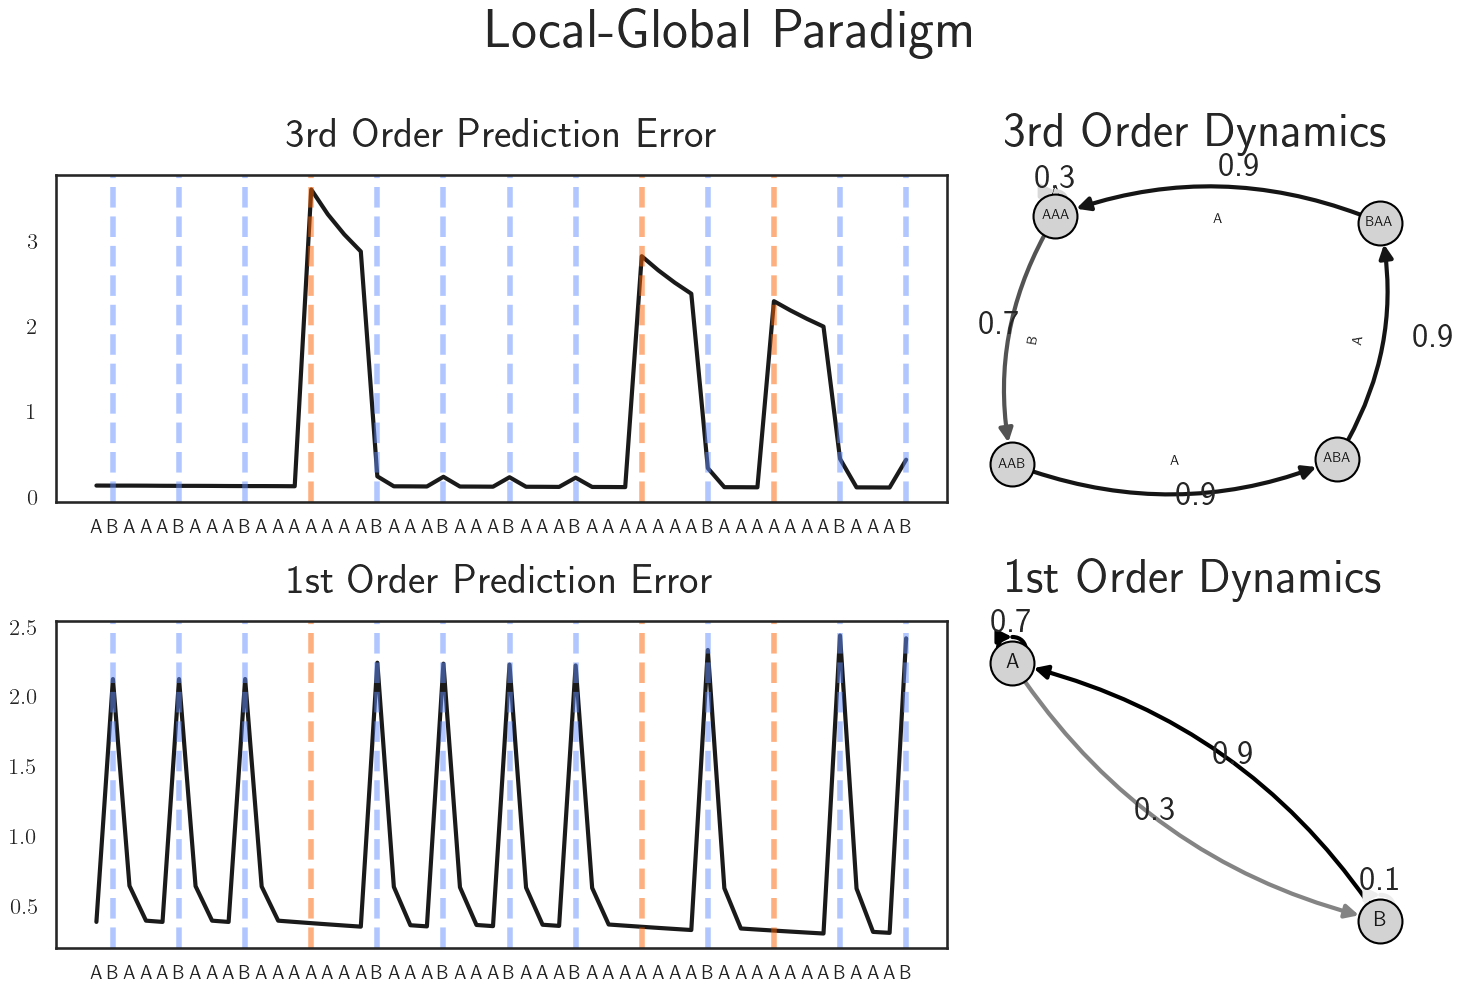

In [31]:
fig, ax = plt.subplots(2, 2, figsize=(5*3, 5*2))

thr = 0.05

gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])
ax1 = plt.subplot(gs[1, 0])
ax2 = plt.subplot(gs[0, 1])
ax3 = plt.subplot(gs[0, 0])
ax4 = plt.subplot(gs[1, 1])

states = ['A', 'B']

last = 50

sns.lineplot(np.array(local_level.bayesian_surprise_hist)[-last:], ax=ax1, c='k', linewidth=3)
ax1.set_title('1st Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax1.set_xticks(np.arange(last), [states[elem] for elem in sequence[-last:]], fontweight='bold', fontsize=14)

sns.lineplot(np.array(global_level.bayesian_surprise_hist)[-last:], ax=ax3, c='k', linewidth=3)
ax3.set_title('3rd Order Prediction Error', fontweight='bold', fontsize=30, pad=20)
ax3.set_xticks(np.arange(last), [states[elem] for idx,elem in enumerate(sequence[-last:])], fontweight='bold', fontsize=14)

local_errors = [0 if elem==0 else 1 for elem in sequence[-last:]]
for idx, err in enumerate(local_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#648fff', linestyle='--', alpha=0.5, linewidth=4)

global_errors = [1 if idx>2 and sum(sequence[-last:][idx-3:idx+4])==0 else 0 for idx,elem in enumerate(sequence[-last:])]
for idx, err in enumerate(global_errors):
    if err:
        ax1.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)
        ax3.axvline(idx, 0, ymax=1, c='#fe6100', linestyle='--', alpha=0.5, linewidth=4)


################################################################################################################

viz.create_digraph(model=local_level, states=['A', 'B'], axis=ax4, thr=thr)

################################################################################################################

G = nx.DiGraph()
edges = [
    ('AAA', 'AAA', 'A'),
    ('AAA', 'AAB', 'B'),
    ('AAB', 'ABA', 'A'),
    ('ABA', 'BAA', 'A'),
    ('BAA', 'AAA', 'A'),
]

edge_labels_code = {
    ('AAA', 'AAA'): 'A',
    ('AAA', 'AAB'): 'B',
    ('AAB', 'ABA'): 'A',
    ('ABA', 'BAA'): 'A',
    ('BAA', 'AAA'): 'A'
}

weights = [global_level.W[0][0], global_level.W[0][1], global_level.W[1][0], global_level.W[2][0], global_level.W[2][0]]

for idx, (u, v, label) in enumerate(edges):
    G.add_edge(u, v, label=label, weight=weights[idx])

pos = nx.spring_layout(G)

edge_labels = nx.get_edge_attributes(G, 'weight')
norm = mcolors.Normalize(vmin=0., vmax=1.)
cmap = plt.cm.Greys
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_colors = [cmap(norm(G[u][v]['weight'])) for u, v in G.edges()]

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_code, ax=ax2)

nx.draw(G, pos, with_labels=True, node_size=1000, node_color='lightgray', font_size=10, font_weight='bold',
        arrows=True, edgecolors='black', edge_color=edge_colors, connectionstyle='arc3,rad=0.2', arrowsize=20, width=3, ax=ax2)

for (u, v), w in edge_labels.items():
    if w > thr:
        if u != v:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            dx, dy = x2 - x1, y2 - y1
            perp_offset = -0.3  # Increase for more distance from edge
            norm = np.sqrt(dx**2 + dy**2)
            ox, oy = -dy / norm * perp_offset, dx / norm * perp_offset
            ax2.text(mx + ox, my + oy, f"{w:.1f}", fontsize=25, bbox=dict(facecolor='none', edgecolor='none'))
        else:
            x, y = pos[u]
            ax2.text(x, y + 0.25, f"{w:.1f}", fontsize=25, va='center', ha='center', bbox=dict(facecolor='none', edgecolor='none'))
for node in states:
    if G.has_edge(node, node):
        x, y = pos[node]
        offset = 0.2
        ax2.add_patch(FancyArrowPatch((x + offset, y + offset), (x + offset, y + offset), connectionstyle="arc3,rad=0.5",  arrowstyle='->', arrowsize=20, mutation_scale=20, color='black', lw=1.5))

ax2.axis('off')
ax2.set_title(global_level.model_name, fontweight='bold', fontsize=35, pad=20)

for ax in ax.ravel():
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Local-Global Paradigm', fontweight='bold', fontsize=40, y=1.0)
plt.tight_layout()
plt.savefig('./results/local_global_paradigm.png', transparent=True)
plt.show()


In [32]:
gt_local = np.array([[.7, .3],[1., 0.]])

local_jsds = np.array([jsd_avg(gt_local, W) for W in local_level.W_hist])

gt_global = np.array([
    [0., 1.], # AAA
    [1., 0.], # AAB
    [1., 0.], # ABA
    [.5, .5], # ABB remove
    [1., 0.], # BAA
    [.5, .5], # BAB remove
    [.5, .5], # BBA remove
    [.5, .5]  # BBB
])

global_jsds = np.array([jsd_avg(gt_global, W) for W in global_level.W_hist])

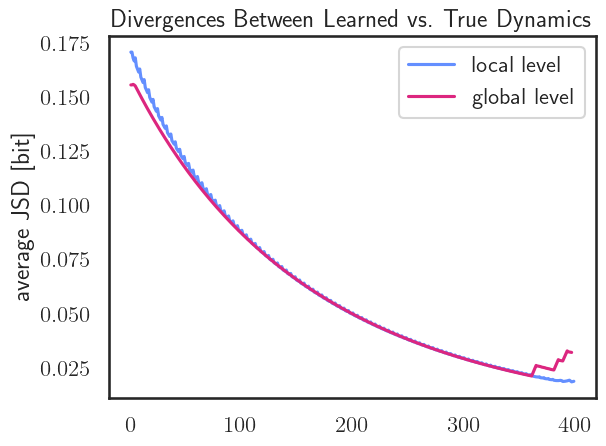

In [33]:
sns.lineplot(local_jsds, label='local level')
sns.lineplot(global_jsds, label='global level')
plt.title('Divergences Between Learned vs. True Dynamics')
plt.ylabel('average JSD [bit]')
plt.tight_layout()
plt.savefig('./results/simulation3_jsds.png', dpi=300)
plt.show()

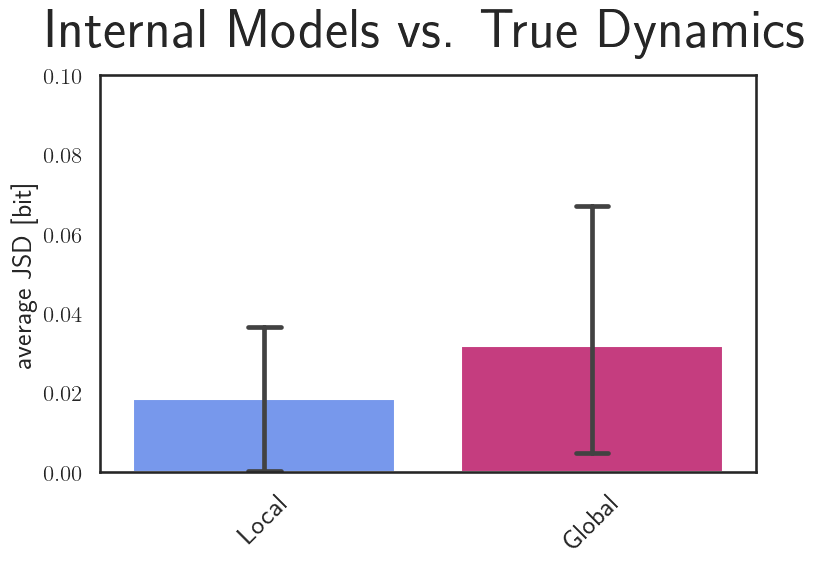

In [34]:
gt_local = np.array([[.7, .3],[1., 0.]])

local_jsds = np.array([jsd(p,q) for p,q in zip(gt_local, local_level.W)]).T

gt_global = np.array([
    [0., 1.], # AAA
    [1., 0.], # AAB
    [1., 0.], # ABA
    [.5, .5], # ABB remove
    [1., 0.], # BAA
    [.5, .5], # BAB remove
    [.5, .5], # BBA remove
    [.5, .5]  # BBB
])

global_jsds = np.array([jsd(p,q) for p,q in zip(gt_global, global_level.W)]).T

plt.figure(figsize=(8, 6))
ax= sns.barplot([local_jsds, global_jsds], capsize=0.1)
ax.set_xticks(range(2), ['Local', 'Global'], fontweight='bold', fontsize=20, rotation=45)
ax.set_ylim(0, .1)
plt.title('Internal Models vs. True Dynamics', fontweight='bold', fontsize=40, pad=20)
plt.ylabel('average JSD [bit]', fontweight='bold', fontsize=20)
plt.tight_layout()
plt.savefig('./results/simulation3_jsds_bar.png', dpi=300)
plt.show()

---